In [565]:
library(readxl)

library(readxl)
library(ggfortify)
library(edgeR)
library(ggpubr)
library(ggrepel)
library(randomForest)
library(ggplotify)
library(RColorBrewer)
library(pROC)
library(data.table)


Loading required package: limma

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




In [188]:
importance = read.table('../data/var_importance.all_clusters.csv',sep=',')
minimal_signature = head(importance,-90)

In [189]:
meta_merged = read.csv('../data/merged_dataset_meta.csv')
data_merged = read.csv('../data/merged_dataset.csv')[,rownames(minimal_signature)]

In [158]:
clinical_info_miracle = read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=2)
clinical_info_became = read_xlsx('../data/BECAME-1_Donnees_cliniques_Working_doc_20Oct2021.xlsx',sheet=1)

New names:
• `ID-LCMS` -> `ID-LCMS...1`
• `ID-LCMS` -> `ID-LCMS...16`


In [159]:
became = list(
    'numerical' = c('age','BMI',
                    'gfr_CKDepi',
                    'ST2 ng/mL',
                    'Ct_FGF23_ELISARUmL',
                    'NTproBNP',
                    'Tropo_T',
                    'LA_Vol_simpsoni',
                    'septalEeprim',
                    'MeanVDOD',
                    'LVEndoGLS',
                    'LVMigm2',
                    'ECVpc',
                    'dosageMyo1',
                    'Hb_gdL',
                    'EFsimpson','Mean_TAPSE','RVEndoGLSSib'),
    
    'ordinal' = c('NYHA','E_A'),
    
    'categorical' = c('sex',
                      'Diabete',
                      'BPCO',
                      'SAS',
                      'loopdiuretics',
                      'CMI',
                      'FA_ATCD')
)

In [160]:
sub_clinical_became = clinical_info_became[,c('ech# Lipidomique',unlist(became))]
colnames(sub_clinical_became)[1] = 'ID'
sub_clinical_became = data.frame(sub_clinical_became)
sub_clinical_became[,1] = paste0('X',sub_clinical_became[,1])

rows = rownames(data_merged)[rownames(data_merged)%in%sub_clinical_became[,1]]
sub_clinical_became = subset(sub_clinical_became,sub_clinical_became[,1]!='XNA')
rownames(sub_clinical_became) = sub_clinical_became[,1]
sub_clinical_became = sub_clinical_became[rows,]
data_merged_became = data_merged[rows,]

In [161]:
options(warn = -1)

results_became = data.frame()
for(i in 1:ncol(data_merged_became)){
    for(group in names(became)){
        for(var in became[[group]]){
            if(group == 'numerical'){
                var = gsub(' |/','.',var)
                tmp = data.frame(cbind(as.numeric(data_merged_became[,i]),as.numeric(sub_clinical_became[,var])))
                tmp = na.omit(tmp)
                test = cor.test(as.numeric(tmp[,1]),as.numeric(tmp[,2]))
                pval = test$p.value
            }else if(group == 'ordinal'){
                var = gsub(' |/','.',var)
                tmp = data.frame(cbind(data_merged_became[,i],sub_clinical_became[,var]))
                tmp = na.omit(tmp)
                tmp[,2] = factor(tmp[,2],levels=unique(tmp[order(as.numeric(tmp[,2])),2]))
                test = kruskal.test(tmp[,1] ~ tmp[,2]) 
                pval = test$p.value
            }else{
                var = gsub(' |/','.',var)
                tmp = data.frame(cbind(data_merged_became[,i],sub_clinical_became[,var]))
                tmp = na.omit(tmp)
                tmp[,2] = factor(tmp[,2],levels=unique(tmp[order(as.numeric(tmp[,2])),2]))
                test = aov(tmp[,1] ~ tmp[,2])   
                pval = summary(test)[[1]][1,'Pr(>F)']
            }
            vec = c(pval,var,colnames(data_merged_became)[i])
            results_became = rbind(results_became,vec)
        }
    }
}
            

In [162]:
colnames(results_became) = c('pval','var','lipid')
results_became[,1] = as.numeric(results_became[,1])

d = reshape2::dcast(var~lipid,data=results_became,value.var='pval')
rownames(d) = d[,1]
d = d[,-1]
selected_rows <- apply(d, 1, function(row) any(row < 0.01))

# Keep only the selected rows
filtered_mat <- d[selected_rows, ]

In [163]:
colnames(filtered_mat) = minimal_signature[colnames(filtered_mat),'lipid_id_became']

In [164]:

ph = pheatmap::pheatmap(-log10(filtered_mat),
                    border_col='white',
                    cutree_cols=5,clustering_method='ward.D2',silent=T)

In [165]:
gaps = c(9,9+9,9+9+21,9+9+21+6)

In [166]:
library(RColorBrewer)

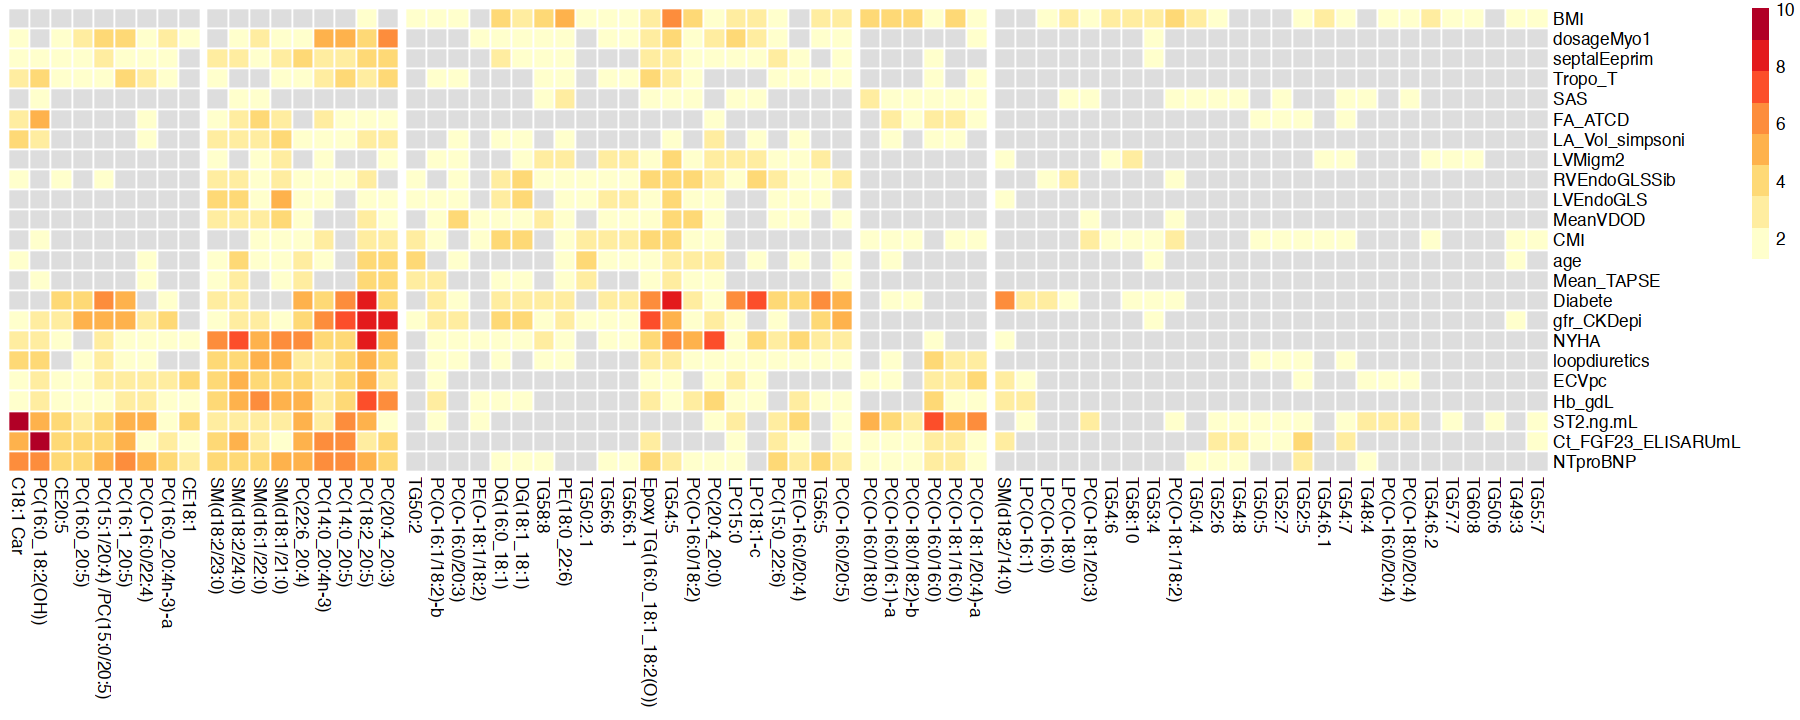

In [167]:
options(repr.plot.width = 15, repr.plot.height = 6)

filtered_mat_cpy = -log10(filtered_mat)
filtered_mat_cpy[filtered_mat_cpy<(-log10(0.05))] = NA
pheatmap::pheatmap(filtered_mat_cpy[ph$tree_row$labels[ph$tree_row$order],ph$tree_col$labels[ph$tree_col$order]],
                    border_col='white',
                    cutree_cols=5,cluster_cols=F,cluster_rows=F,gaps_col=gaps,col=brewer.pal(8,'YlOrRd'))

In [ ]:
find_pvals<-function(data){
    p_values <- matrix(NA, nrow = ncol(data), ncol = ncol(data))
    
    # Loop through each pair of features
    for (i in 1:(ncol(data) - 1)) {
      for (j in (i + 1):ncol(data)) {
        
        # Perform correlation test
        if(is.numeric(data[,i])&is.numeric(data[,j])){
            correlation_test <- cor.test(as.numeric(data[, i]), as.numeric(data[, j]))
        
            # Store p-value in the matrix
            p_values[i, j] <- correlation_test$p.value
            p_values[j, i] <- correlation_test$p.value
        }
      }
    }
    p_values = data.frame(p_values)
    colnames(p_values) = colnames(data)
    rownames(p_values) = colnames(data)
    return(p_values)
}

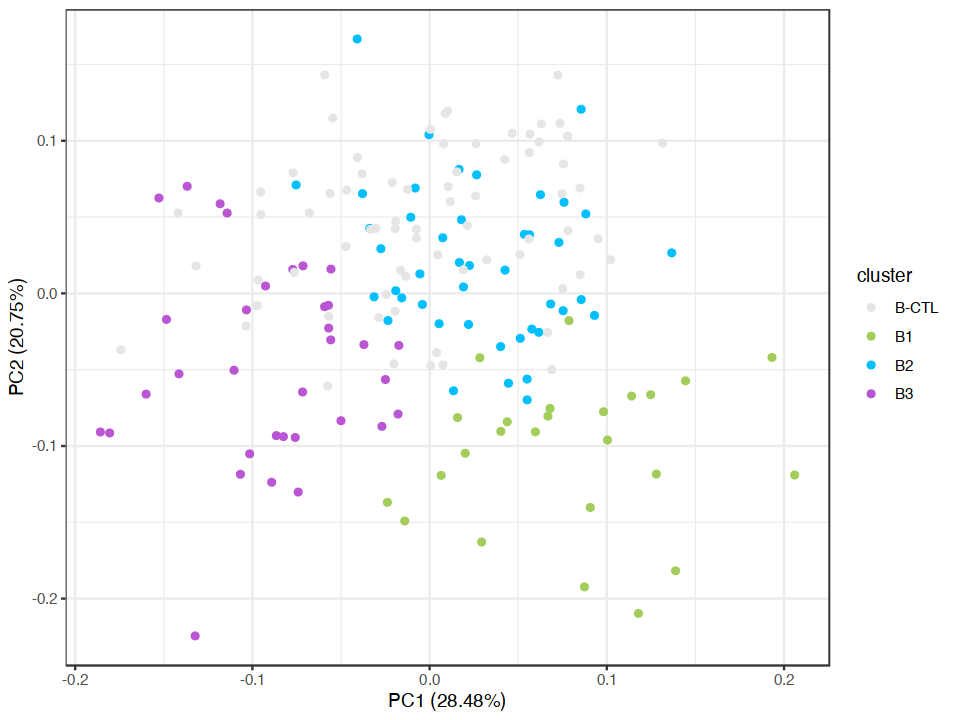

In [168]:
options(repr.plot.width = 8, repr.plot.height = 6)

library(ggfortify)
autoplot(prcomp(data_merged_became[,rownames(minimal_signature)]),data=meta_merged[rownames(data_merged_became),],col='cluster')+theme_bw()+scale_color_manual(values=c('grey90','darkolivegreen3','deepskyblue','mediumorchid'))

In [169]:
miracle = list(
    'numerical' = c('Age','IMC'),  
    'categorical' = c('Sex',
                      'Diabete')
)

In [170]:
sub_clinical_miracle = clinical_info_miracle[,c('ID-LCMS...1',unlist(miracle))]
colnames(sub_clinical_miracle)[1] = 'ID'
sub_clinical_miracle = data.frame(sub_clinical_miracle)
sub_clinical_miracle[,1] = paste0('X',sub_clinical_miracle[,1])

rows = rownames(data_merged)[rownames(data_merged)%in%sub_clinical_miracle[,1]]
sub_clinical_miracle = subset(sub_clinical_miracle,sub_clinical_miracle[,1]!='XNA')
rownames(sub_clinical_miracle) = sub_clinical_miracle[,1]
sub_clinical_miracle = sub_clinical_miracle[rows,]
data_merged_miracle = data_merged[rows,]

In [171]:
options(warn = -1)

results_miracle = data.frame()
for(i in 1:ncol(data_merged_miracle)){
    for(group in names(miracle)){
        for(var in miracle[[group]]){
            if(group == 'numerical'){
                var = gsub(' |/','.',var)
                tmp = data.frame(cbind(as.numeric(data_merged_miracle[,i]),as.numeric(sub_clinical_miracle[,var])))
                tmp = na.omit(tmp)
                test = cor.test(as.numeric(tmp[,1]),as.numeric(tmp[,2]))
                pval = test$p.value
            }else if(group == 'ordinal'){
                var = gsub(' |/','.',var)
                tmp = data.frame(cbind(data_merged_miracle[,i],sub_clinical_miracle[,var]))
                tmp = na.omit(tmp)
                tmp[,2] = factor(tmp[,2],levels=unique(tmp[order(as.numeric(tmp[,2])),2]))
                test = kruskal.test(tmp[,1] ~ tmp[,2]) 
                pval = test$p.value
            }else{
                var = gsub(' |/','.',var)
                tmp = data.frame(cbind(data_merged_miracle[,i],sub_clinical_miracle[,var]))
                tmp = na.omit(tmp)
                tmp[,2] = factor(tmp[,2],levels=unique(tmp[order(as.numeric(tmp[,2])),2]))
                test = aov(tmp[,1] ~ tmp[,2])   
                pval = summary(test)[[1]][1,'Pr(>F)']
            }
            vec = c(pval,var,colnames(data_merged_miracle)[i])
            results_miracle = rbind(results_miracle,vec)
        }
    }
}
            

In [172]:
colnames(results_miracle) = c('pval','var','lipid')
results_miracle[,1] = as.numeric(results_miracle[,1])

d = reshape2::dcast(var~lipid,data=results_miracle,value.var='pval')
rownames(d) = d[,1]
d = d[,-1]
selected_rows <- apply(d, 1, function(row) any(row < 0.01))

# Keep only the selected rows
filtered_mat <- d[selected_rows, ]

In [173]:
colnames(filtered_mat) = minimal_signature[colnames(filtered_mat),'lipid_id_miracle']

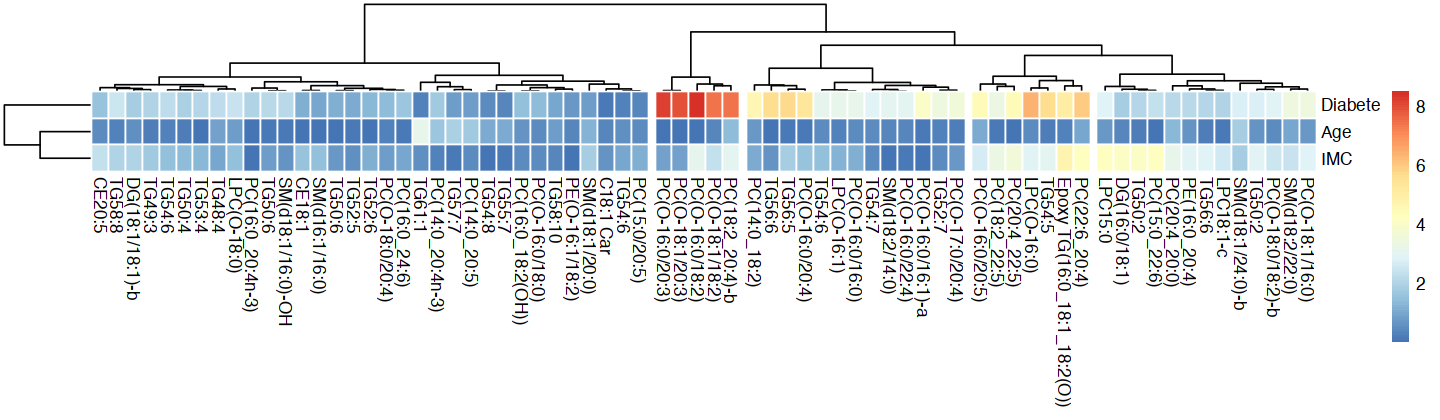

In [174]:
options(repr.plot.width = 12, repr.plot.height = 3.5)

ph = pheatmap::pheatmap(-log10(filtered_mat),
                    border_col='white',
                    cutree_cols=5,clustering_method='ward.D2')

In [175]:
results_became = subset(results_became,var%in%c('age','sex','BMI','Diabete'))
results_became$var[results_became$var=='age'] = 'Age'
results_became$var[results_became$var=='sex'] = 'Sex'
results_became$var[results_became$var=='BMI'] = 'IMC'
results_became$id = paste(results_became$var,results_became$lipid,sep='_')
rownames(results_became) = results_became$id


results_miracle$id = paste(results_miracle$var,results_miracle$lipid,sep='_')
rownames(results_miracle) = results_miracle$id

results_miracle$pval_became = results_became[rownames(results_miracle),'pval']
head(results_miracle)

,pval,var,lipid,id,pval_became
,<dbl>,<chr>,<chr>,<chr>,<dbl>
Age_X51,0.4997912287,Age,X51,Age_X51,0.498097530
IMC_X51,0.1466960302,IMC,X51,IMC_X51,0.000107550
Sex_X51,0.5380653508,Sex,X51,Sex_X51,0.062387516
Diabete_X51,0.0368004656,Diabete,X51,Diabete_X51,0.285360158
Age_X43,0.8279955901,Age,X43,Age_X43,0.019912144
IMC_X43,0.0007500483,IMC,X43,IMC_X43,0.006795321


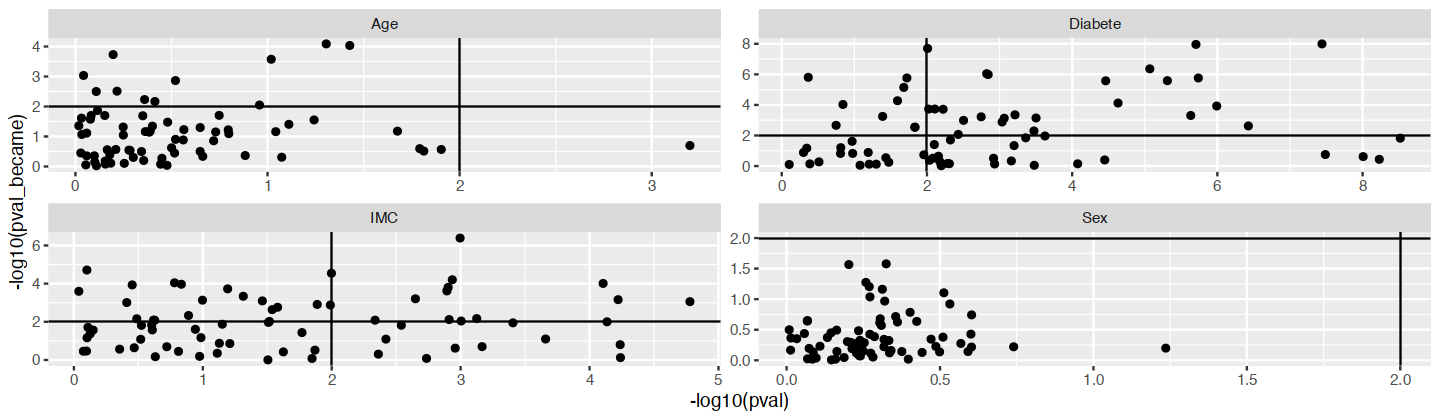

In [182]:
library(ggplot2)
ggplot(results_miracle,aes(-log10(pval),-log10(pval_became)))+
    geom_hline(yintercept=-log10(0.01))+
    geom_vline(xintercept=-log10(0.01))+geom_point()+facet_wrap(~var,scales='free')

In [194]:
t = table(meta_merged[,c('cluster','preds')])
for(i in 1:nrow(t)){t[i,]=t[i,]/sum(t[i,])}

In [203]:
t = data.frame(t)
t$cohort = 'MIRACLE'
t[grepl('^B',t$cluster),'cohort'] = 'BECAME'

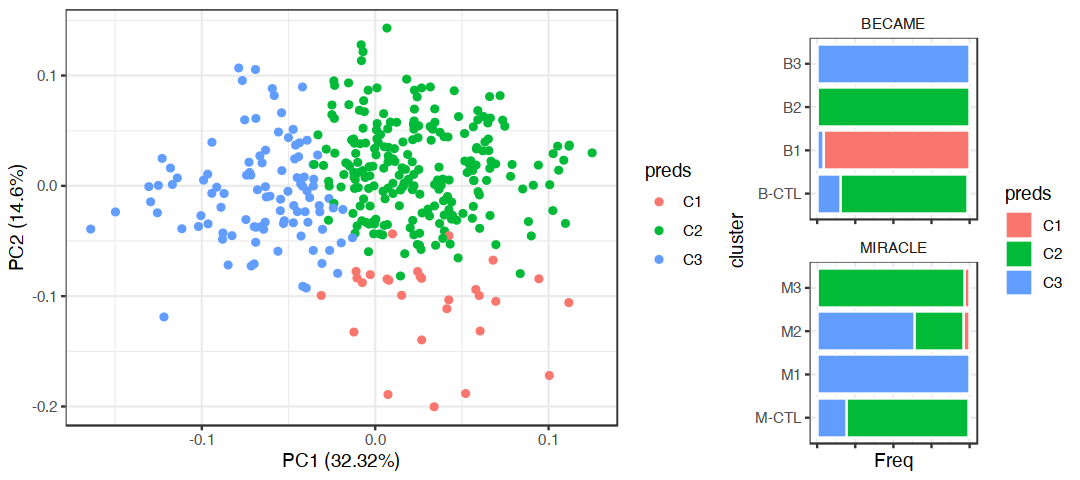

In [218]:
options(repr.plot.width = 9, repr.plot.height = 4)

p1= autoplot(prcomp(data_merged[,rownames(minimal_signature)]),data=meta_merged,col='preds')+theme_bw()
p2=ggplot(t,aes(cluster,Freq,fill=preds))+geom_col(col='white')+theme_bw()+theme(strip.background=element_blank(),axis.text.x=element_blank())+facet_wrap(cohort~.,scales='free',ncol=1)
cowplot::plot_grid(p1,p2+coord_flip(),rel_widths=c(2,1))

In [220]:
install.packages('coin')

Installing package into ‘/Users/otastet/Library/R/x86_64/4.2/library’
(as ‘lib’ is unspecified)

also installing the dependency ‘libcoin’





The downloaded binary packages are in
	/var/folders/qy/m3n_w10n31q06s6_0fk1_j800000gn/T//RtmpUhBmJ5/downloaded_packages


In [223]:
data_merged_became$cluster

[1] "B3"    "B2"    "B2"    "B2"    "B1"    "B1"    "B2"    "B2"    "B2"   
 [10] "B3"    "B2"    "B3"    "B3"    "B2"    "B2"    "B2"    "B3"    "B1"   
 [19] "B2"    "B2"    "B3"    "B1"    "B3"    "B1"    "B2"    "B3"    "B2"   
 [28] "B2"    "B1"    "B3"    "B3"    "B3"    "B1"    "B3"    "B1"    "B1"   
 [37] "B1"    "B2"    "B1"    "B2"    "B1"    "B3"    "B3"    "B1"    "B3"   
 [46] "B2"    "B2"    "B1"    "B2"    "B1"    "B3"    "B1"    "B2"    "B2"   
 [55] "B3"    "B1"    "B3"    "B3"    "B2"    "B2"    "B2"    "B2"    "B2"   
 [64] "B3"    "B3"    "B2"    "B3"    "B1"    "B2"    "B2"    "B1"    "B3"   
 [73] "B2"    "B2"    "B3"    "B2"    "B1"    "B1"    "B2"    "B3"    "B1"   
 [82] "B2"    "B3"    "B2"    "B1"    "B3"    "B3"    "B3"    "B3"    "B3"   
 [91] "B2"    "B2"    "B2"    "B1"    "B3"    "B3"    "B3"    "B2"    "B1"   
[100] "B2"    "B2"    "B2"    "B2"    "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL"
[109] "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL"
[118] "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL"
[127] "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL"
[136] "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL"
[145] "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL"
[154] "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL"
[163] "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL" "B-CTL"
[172] "B-CTL" "B-CTL" "B-CTL" "B-CTL"

In [224]:
as.numeric(sub_clinical_became[,var])

[1] 73 65 69 73 81 70 70 51 69 71 81 53 56 84 83 73 79 85 81 77 83 83 71 72 65
 [26] 83 82 73 72 84 83 84 72 85 69 80 70 80 79 74 75 83 73 73 76 77 84 71 78 83
 [51] 74 68 83 74 84 67 62 78 66 84 82 75 69 75 85 78 84 67 80 73 85 66 81 79 72
 [76] 71 76 78 67 79 78 79 83 77 81 81 73 84 80 67 71 80 76 85 83 66 82 75 68 81
[101] 78 79 68 45 65 71 80 75 67 65 53 57 67 71 75 64 77 49 54 56 70 77 76 73 61
[126] 68 71 77 73 57 41 53 79 77 72 59 66 37 45 47 54 60 72 76 67 38 49 56 64 68
[151] 65 77 72 43 52 58 60 81 68 68 75 44 52 58 62 75 66 80 38 45 58 59 84 73 66

In [254]:
results_became = data.frame()
data_merged_became$cluster = meta_merged[rownames(data_merged_became),'cluster']
for(group in names(became)){
        for(var in became[[group]]){
            if(group == 'numerical'){
                var = gsub(' |/','.',var)
                tmp = data.frame(cbind(data_merged_became[,'cluster'],as.numeric(sub_clinical_became[,var])))
                tmp = tmp[which(tmp[,1]!='B-CTL'),]
                tmp = na.omit(tmp)
                test = aov(as.numeric(tmp[,2])~as.factor(tmp[,1]))
                pval = summary(test)[[1]][1,'Pr(>F)']
            }else if(group == 'ordinal'){
                var = gsub(' |/','.',var)
                tmp = data.frame(cbind(data_merged_became[,'cluster'],sub_clinical_became[,var]))
                tmp = tmp[which(tmp[,1]!='B-CTL'),]
                tmp = na.omit(tmp)
                tmp[,2] = factor(tmp[,2],levels=unique(tmp[order(as.numeric(tmp[,2])),2]))
                result <- chisq.test(table(tmp))
                pval = result$p.value
            }else{
                var = gsub(' |/','.',var)
                tmp = data.frame(cbind(data_merged_became[,'cluster'],sub_clinical_became[,var]))
                tmp = tmp[which(tmp[,1]!='B-CTL'),]
                tmp = na.omit(tmp)
                tmp[,2] = factor(tmp[,2],levels=unique(tmp[order(as.numeric(tmp[,2])),2]))
                result <- chisq.test(table(tmp))
                pval = result$p.value
            }
            vec = c(pval,var,colnames(data_merged_became)[i])
            results_became = rbind(results_became,vec)
        }
    }

In [259]:
colnames(results_became) = c('pval','var','lipid')
results_became[,1] = as.numeric(results_became[,1])


In [263]:
subset(results_became,pval<0.1)

,pval,var,lipid
,<dbl>,<chr>,<chr>
2,0.0585012995,BMI,X41
3,0.0021691045,gfr_CKDepi,X41
4,0.0022835025,ST2.ng.mL,X41
5,0.0005195635,Ct_FGF23_ELISARUmL,X41
6,0.0090102151,NTproBNP,X41
12,0.0006051709,LVMigm2,X41
14,0.0679477503,dosageMyo1,X41
22,0.0750142874,Diabete,X41
24,0.0994608241,SAS,X41


In [285]:
plot_cat<-function(var){
    tmp = data.frame(cbind(data_merged_became[,'cluster'],sub_clinical_became[,var]))
    tmp = na.omit(tmp)
    tmp[,2] = factor(tmp[,2],levels=unique(tmp[order(as.numeric(tmp[,2])),2]))
    t = table(tmp)
    for(i in 1:nrow(t)){t[i,]=t[i,]/sum(t[i,])}
    t = data.frame(t)
    return(ggplot(t,aes(X1,Freq,fill=X2))+geom_col())
}

In [296]:
plot_num <- function(var){
    tmp = data.frame(cbind(data_merged_became[,'cluster'],sub_clinical_became[,var]))
    tmp = na.omit(tmp)
    tmp[,1] = factor(tmp[,1])
    tmp[,2] = as.numeric(tmp[,2])
    p=ggplot(tmp,aes(X1,X2,fill=X1))+geom_point(position=position_jitter(width=.1),size=.1)+geom_boxplot(alpha=.7,outlier.shape=NA)+theme_bw()
    return(p)
}

In [299]:
plots=list()
for(i in subset(results_became,pval<0.05)$var){
    if(i %in% became[['numerical']] || i=='ST2.ng.mL'){
        plots[[i]] = plot_num(i)+ylab(i)+xlab('')+guides(fill='none')
    }else{
        plots[[i]] = plot_cat(i)
    }
}

In [301]:
subset(results_became,pval<0.05)$var

[1] "gfr_CKDepi"         "ST2.ng.mL"          "Ct_FGF23_ELISARUmL"
[4] "NTproBNP"           "LVMigm2"

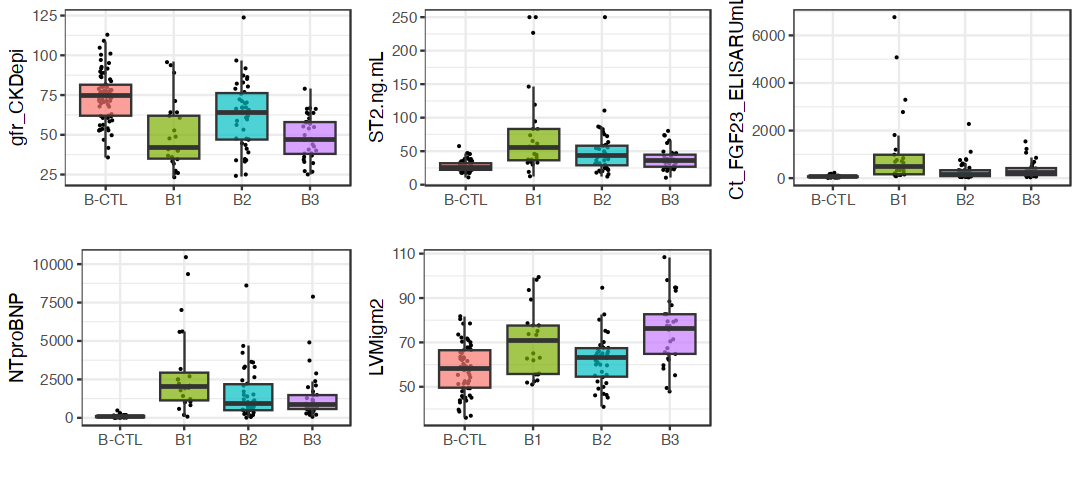

In [300]:
cowplot::plot_grid(plotlist=plots)

In [676]:
head(importance)

,MeanDecreaseGini,lipid_id_became,lipid_id_miracle,lipid_class,modified_became_id
,<dbl>,<chr>,<chr>,<chr>,<chr>
X51,1.6231193,PC(O-18:1/16:0),PC(O-18:0/20:4),Phosphatidylcholine ethers,PC(O-18:1/16:0)
X43,1.1836234,PC(O-16:0/20:3),PC(O-16:0/18:2),Phosphatidylcholine ethers,PC(O-16:0/20:3)
X146,1.1174231,TG55:7,TG55:7,Triglycerides,TG55:7
X49,0.9758354,PC(O-18:0/18:2)-b,PC(O-17:0/20:4),Phosphatidylcholine ethers,PC(O-18:0/18:2)-b
X154,0.9365520,TG57:7,TG57:7,Triglycerides,TG57:7
X127,0.8801183,TG50:5,TG50:6,Triglycerides,TG50:5__2


In [709]:
importance[c('X151','X71'),]

,MeanDecreaseGini,lipid_id_became,lipid_id_miracle,lipid_class,modified_became_id
,<dbl>,<chr>,<chr>,<chr>,<chr>
X151,0.358765,TG56:6,TG56:6,Triglycerides,TG56:6__3
X71,0.611070,PC(16:1_20:5),PC(16:0_24:6),Phosphatidylcholines,PC(16:1_20:5)


In [699]:
tmp = na.omit(reshape2::melt(p_values))
head(tmp[order(-tmp$value),],10)

Using id as id variables



,id,variable,value
,<chr>,<fct>,<dbl>
4401,X86,X105,0.9937779
4961,X105,X86,0.9937779
88,X71,X43,0.9856146
1138,X43,X71,0.9856146
1178,X151,X71,0.9843251
2928,X71,X151,0.9843251
2266,X67,X123,0.9832707
4576,X123,X67,0.9832707
1605,X81,X144,0.9822848


In [692]:
colnames(data.frame(mat))

[1] "PC.O.18.1.16.0."              "PC.O.16.0.20.3."             
 [3] "TG55.7"                       "PC.O.18.0.18.2..b"           
 [5] "TG57.7"                       "TG50.5"                      
 [7] "PC.15.1.20.4...PC.15.0.20.5." "PC.O.16.0.18.0."             
 [9] "TG54.6"                       "DG.18.1_18.1."               
[11] "TG50.6"                       "PC.15.0_22.6."               
[13] "TG52.7"                       "TG50.2"                      
[15] "CE20.5"                       "TG54.7"                      
[17] "PC.16.1_20.5."                "PC.14.0_20.5."               
[19] "PC.22.6_20.4."                "TG54.5"                      
[21] "PC.O.18.1.20.3."              "TG58.10"                     
[23] "TG54.8"                       "TG52.5"                      
[25] "TG49.3"                       "TG56.6"                      
[27] "C18.1.Car"                    "TG54.6.1"                    
[29] "TG58.8"                       "PE.18.0_22.6."               
[31] "LPC15.0"                      "TG50.2.1"                    
[33] "PC.O.18.1.18.2."              "TG50.4"                      
[35] "PC.18.2_20.5."                "TG48.4"                      
[37] "PC.16.0_20.4n.3..a"           "DG.16.0_18.1."               
[39] "PC.14.0_20.4n.3."             "PC.16.0_18.2.OH.."           
[41] "TG56.5"                       "TG56.6.1"                    
[43] "PC.20.4_20.3."                "PE.O.16.0.20.4."             
[45] "PC.O.16.0.20.4."              "PC.O.16.0.16.0."             
[47] "TG53.4"                       "LPC.O.16.1."                 
[49] "SM.d18.1.21.0."               "SM.d18.2.23.0."              
[51] "TG52.6"                       "PC.O.16.0.18.2."             
[53] "TG60.8"                       "TG54.6.2"                    
[55] "SM.d18.2.14.0."               "SM.d16.1.22.0."              
[57] "PC.O.16.1.18.2..b"            "PC.20.4_20.0."               
[59] "CE18.1"                       "LPC.O.18.0."                 
[61] "PC.O.18.1.20.4..a"            "SM.d18.2.24.0."              
[63] "PC.O.18.0.20.4."              "Epoxy.TG.16.0_18.1_18.2.O.." 
[65] "PC.16.0_20.5."                "LPC.O.16.0."                 
[67] "PC.O.16.0.16.1..a"            "PC.O.16.0.20.5."             
[69] "LPC18.1.c"                    "PE.O.18.1.18.2."             
[71] "PC.O.16.0.22.4."

In [708]:
cor.test(data.frame(mat)[,'PC.16.0_20.5.'],data.frame(mat)[,'TG50.2'])


	Pearson's product-moment correlation

data:  data.frame(mat)[, "PC.16.0_20.5."] and data.frame(mat)[, "TG50.2"]
t = 5.2734, df = 350, p-value = 2.35e-07
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1716410 0.3654711
sample estimates:
      cor 
0.2713045 


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


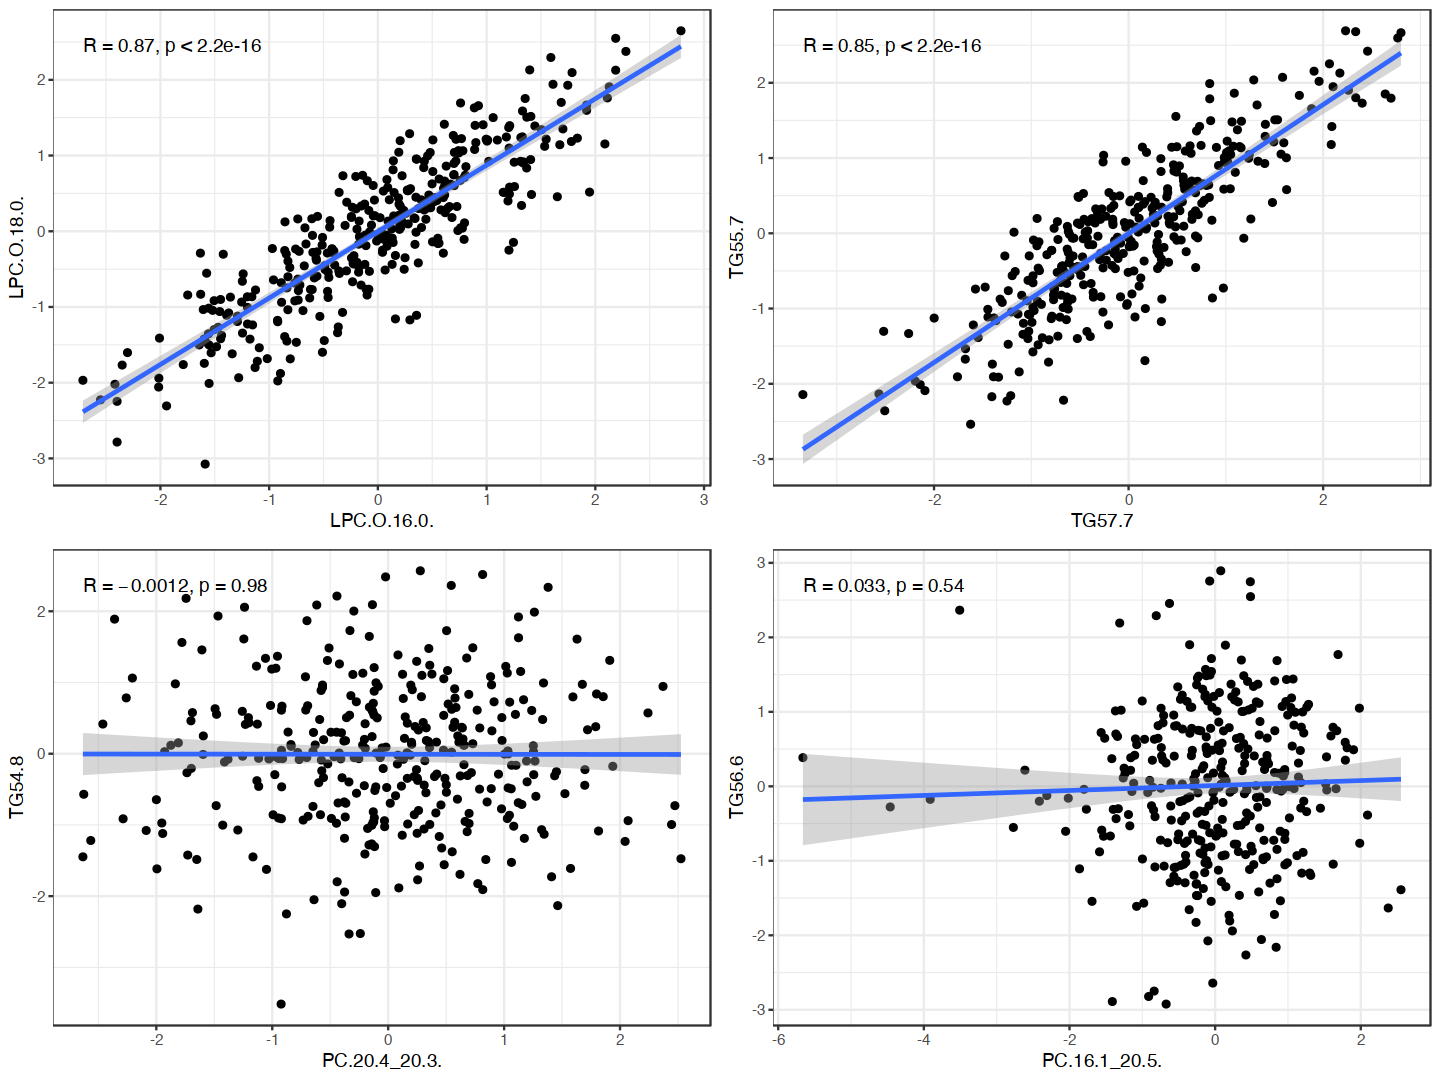

In [710]:
options(repr.plot.width = 12, repr.plot.height = 9)

p1 = ggplot(data.frame(mat),aes(LPC.O.16.0.,LPC.O.18.0.))+geom_point()+stat_cor(method='pearson')+geom_smooth(method='lm')
p2 = ggplot(data.frame(mat),aes(TG57.7,TG55.7))+geom_point()+stat_cor(method='pearson')+geom_smooth(method='lm')
p3 = ggplot(data.frame(mat),aes(PC.20.4_20.3.,TG54.8))+geom_point(method='pearson')+stat_cor()+geom_smooth(method='lm')
p4 = ggplot(data.frame(mat),aes(PC.16.1_20.5.,TG56.6))+geom_point(method='pearson')+stat_cor()+geom_smooth(method='lm')
cowplot::plot_grid(p1+theme_bw(),p2+theme_bw(),p3+theme_bw(),p4+theme_bw(),ncol=2)

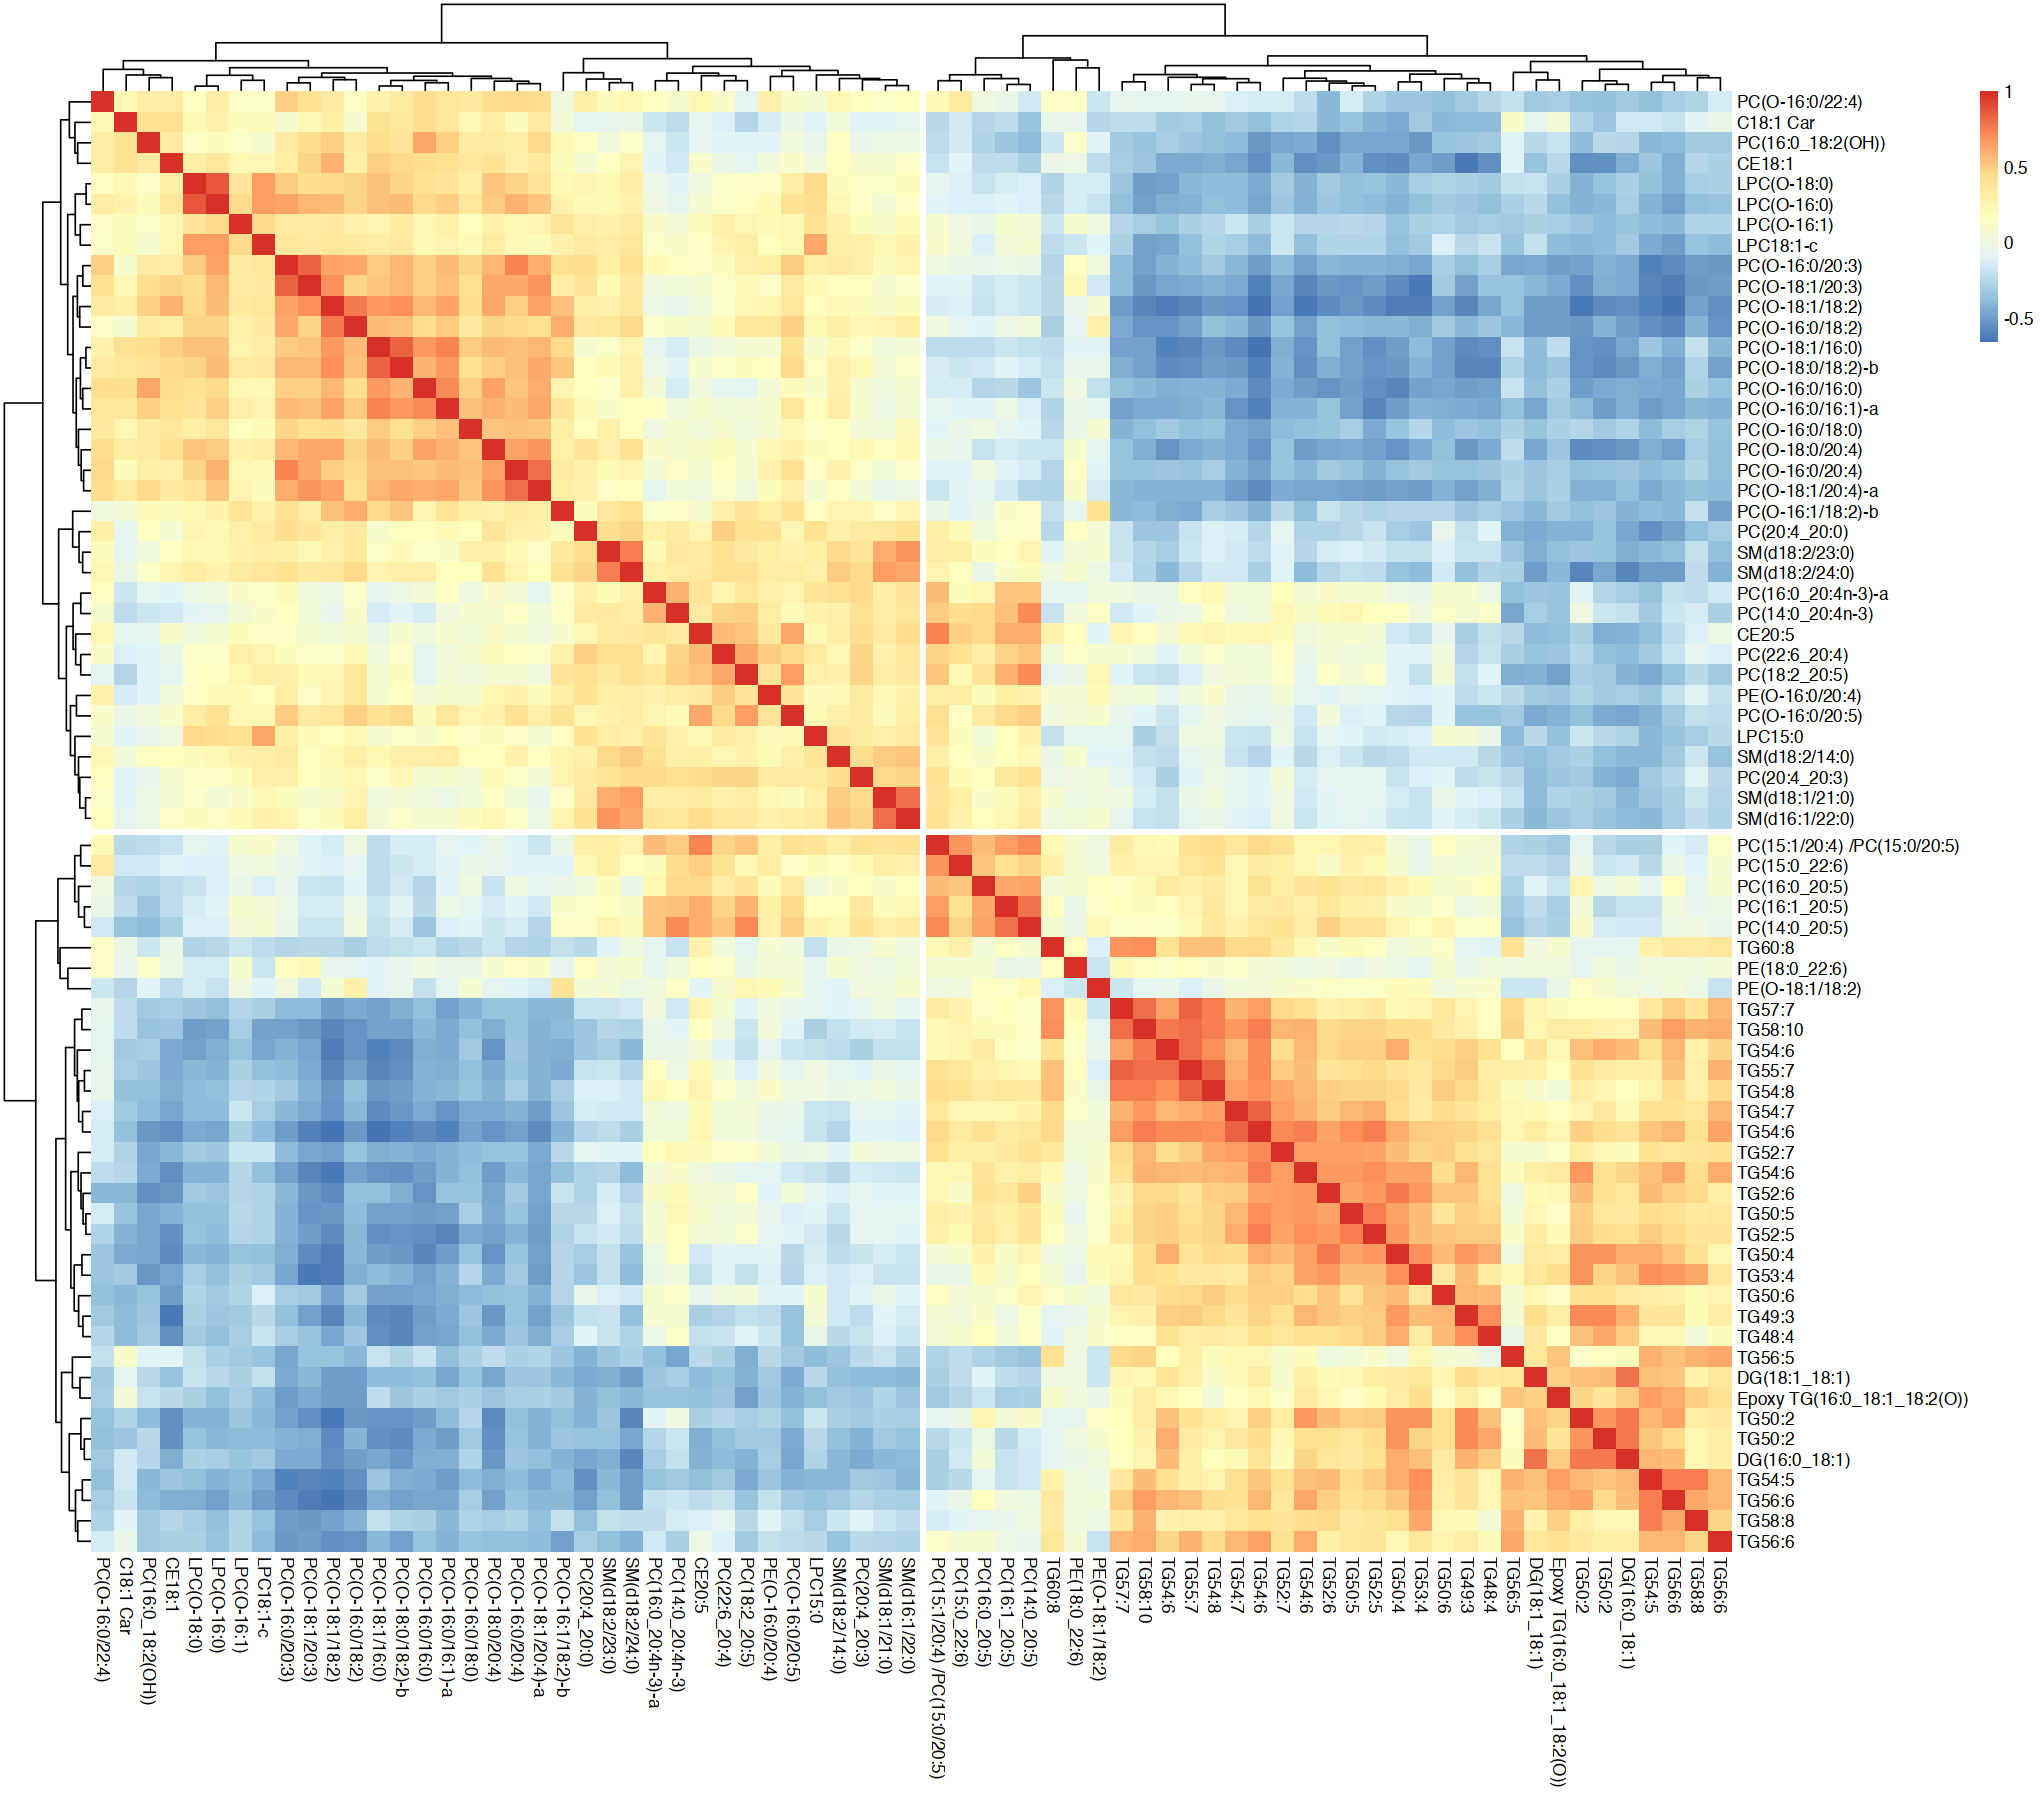

In [717]:
options(repr.plot.width = 17, repr.plot.height = 15)

mat = data_merged[,rownames(minimal_signature)]
colnames(mat) = importance[colnames(mat),'lipid_id_became']

pheatmap::pheatmap(cor(mat),border_col=NA,cutree_cols=2,cutree_rows=2)

In [435]:

find_pvals<-function(data){
p_values <- matrix(NA, nrow = ncol(data), ncol = ncol(data))

# Loop through each pair of features
for (i in 1:(ncol(data) - 1)) {
  for (j in (i + 1):ncol(data)) {
    
    # Perform correlation test
    if(is.numeric(data[,i])&is.numeric(data[,j])){
        correlation_test <- cor.test(as.numeric(data[, i]), as.numeric(data[, j]))
    
        # Store p-value in the matrix
        p_values[i, j] <- correlation_test$p.value
        p_values[j, i] <- correlation_test$p.value
    }
  }
}
p_values = data.frame(p_values)
colnames(p_values) = colnames(data)
rownames(p_values) = colnames(data)
return(p_values)
}

In [343]:
dim(lipid_mat)

[1]  71 353

In [379]:
lipid_mat = data.frame(t(data_merged[,rownames(minimal_signature)]))


for(k in rev(2:70)){
    cor_matrix <- cor(t(lipid_mat))
    
    # Step 2: Perform hierarchical clustering
    dendrogram <- hclust(dist(1 - cor_matrix))  # Using dissimilarity
    
    # Step 3: Cut the dendrogram to form clusters
    num_clusters <- k  # You can choose the number of clusters
    clusters <- cutree(dendrogram, num_clusters)
    lipid_mat$clusters = clusters
    t = table(clusters)
    t = t[t>1]
    remove = c()
    for(i in names(t)){
        tmp = p_values[rownames(lipid_mat[which(lipid_mat$clusters==as.numeric(i)),]),rownames(lipid_mat[which(lipid_mat$clusters==as.numeric(i)),])]
        m = na.omit(reshape2::melt(tmp))
        m = m[order(m$value),]
        remove = c(remove,as.character(subset(m,value<0.01)$variable[2:nrow(subset(m,value<0.01))]))
    }
    lipid_mat = lipid_mat[!rownames(lipid_mat)%in%paste0('X',remove),]
}

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; usi

Using id as id variables



,id,variable,value
,<chr>,<fct>,<dbl>
4255,X12,X14,9.877394e-112
4675,X14,X12,9.877394e-112
147,X154,X146,6.814036e-99
287,X146,X154,6.814036e-99
165,X144,X146,1.036639e-97
1565,X146,X144,1.036639e-97


In [409]:
most_sign

ERROR: Error in eval(expr, envir, enclos): object 'most_sign' not found


In [415]:
p_values = find_pvals(data)

[1] 2.997328e-112

In [425]:
most_sign

,id,variable,value
,<chr>,<fct>,<dbl>
4255,X12,X14,2.997328e-112


In [441]:
dim(data)

[1] 352 352

In [447]:
ph = pheatmap::pheatmap(cor(t(data)),cutree_cols=15,cutree_rows=15,silent=T)

In [483]:
p_values['X51']

,X51
,<dbl>
X51,NA
X43,3.419926e-25
X146,1.625583e-33
X49,1.681359e-93
X154,1.319238e-21
X127,3.318795e-22
X64,8.019778e-05
X41,4.182237e-24
X138,4.357055e-34


In [484]:
clus_names = names(clusters[clusters==i])

Using id as id variables



In [638]:
clusters <- cutree(dendrogram, 30)

In [662]:
keeps=c()
for(i in 1:30){
        clus_names = names(clusters[clusters==i])
        m = na.omit(reshape2::melt(p_values[clus_names,c('id',clus_names)],id.var='id'))
        correlated = unique(subset(m,value<0.01)[,1])
        if(length(correlated)>0){
            tmp = rownames(minimal_signature) %in% correlated
            names(tmp) = rownames(minimal_signature)
            tmp = tmp[tmp==1]
            keep = c(names(tmp)[1],clus_names[!clus_names%in%correlated])
        }else{
            keep = c(clus_names)
        }
        keeps = c(keeps,keep)
    }

In [668]:
clusters=data.frame(clusters)
clusters$clusters=factor(clusters$clusters)

In [669]:
t = table(clusters$clusters)
clusters$cluster2 = as.character(clusters$clusters)
clusters[which(clusters$clusters%in%names(t[t==1])),'cluster2'] = 'single'

In [671]:
clusters$in_keep = rownames(clusters)%in%keeps

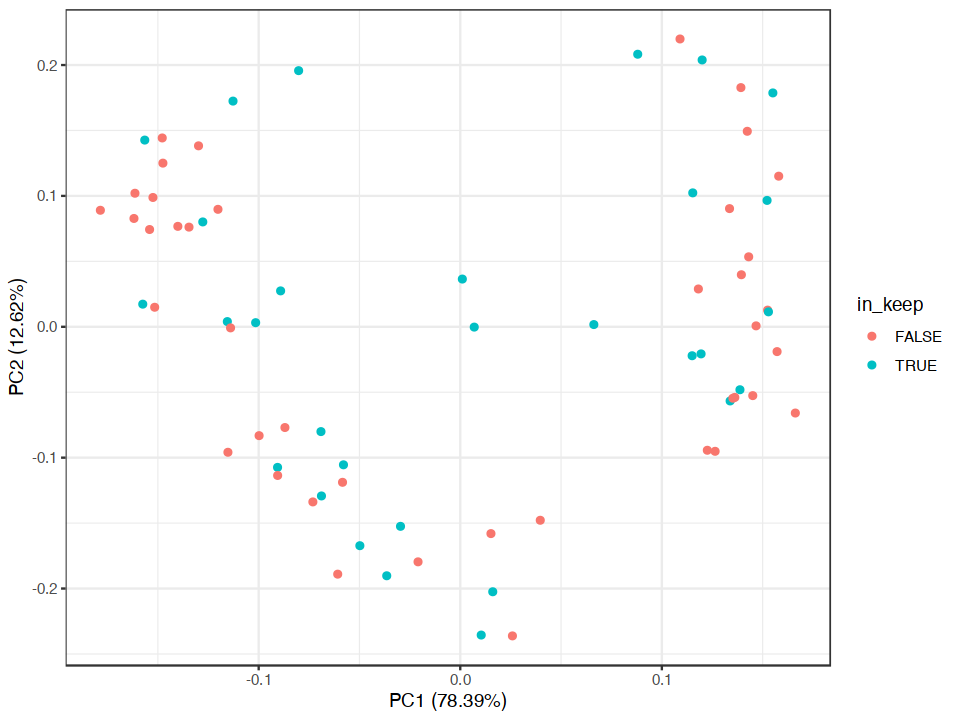

In [672]:
options(repr.plot.width = 8, repr.plot.height = 6)

autoplot(prcomp(cor(lipid_mat)),data=clusters,col='in_keep')+theme_bw()

In [614]:
# Step 1: Calculate correlation matrix
cor_matrix <- cor(lipid_mat)

# Step 2: Perform hierarchical clustering
dendrogram <- hclust(dist(1 - cor_matrix))  # Using dissimilarity

# Step 3: Cut the dendrogram to form clusters
num_clusters <- c(5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 71)
plots = list()
dist_mat = data.frame()
accuracies = c()
for(n in num_clusters){# You can choose the number of clusters
    clusters <- cutree(dendrogram, n)
    keeps = c()
    for(i in 1:n){
        clus_names = names(clusters[clusters==i])
        m = na.omit(reshape2::melt(p_values[clus_names,c('id',clus_names)],id.var='id'))
        correlated = unique(subset(m,value<0.01)[,1])
        if(length(correlated)>0){
            tmp = rownames(minimal_signature) %in% correlated
            names(tmp) = rownames(minimal_signature)
            tmp = tmp[tmp==1]
            keep = c(names(tmp)[1],clus_names[!clus_names%in%correlated])
        }else{
            keep = c(clus_names)
        }
        keeps = c(keeps,keep)
    }
    keeps = na.omit(keeps) 
    pca = data.frame(scale(prcomp(data_merged[,keeps])$x))
    pca$cluster = meta_merged[rownames(pca),'preds']
    ag = aggregate(pca[,1:2],by=list(pca$cluster),mean)
    rownames(ag)= ag[,1]
    r = reshape2::melt(as.matrix(dist(ag[,-1])))
    r = subset(r,Var1!=Var2)
    r = r[!duplicated(r$value),]
    r$label = paste(r$Var1,r$Var2,sep='_')
    r$ncluster = n
    dist_mat = rbind(dist_mat,r)
    acc = make_rf(keeps)
    accuracies = c(accuracies,acc)
    plots[[as.character(n)]] = autoplot(prcomp(data_merged[,keeps]),
             data=meta_merged,col='preds')
    
}

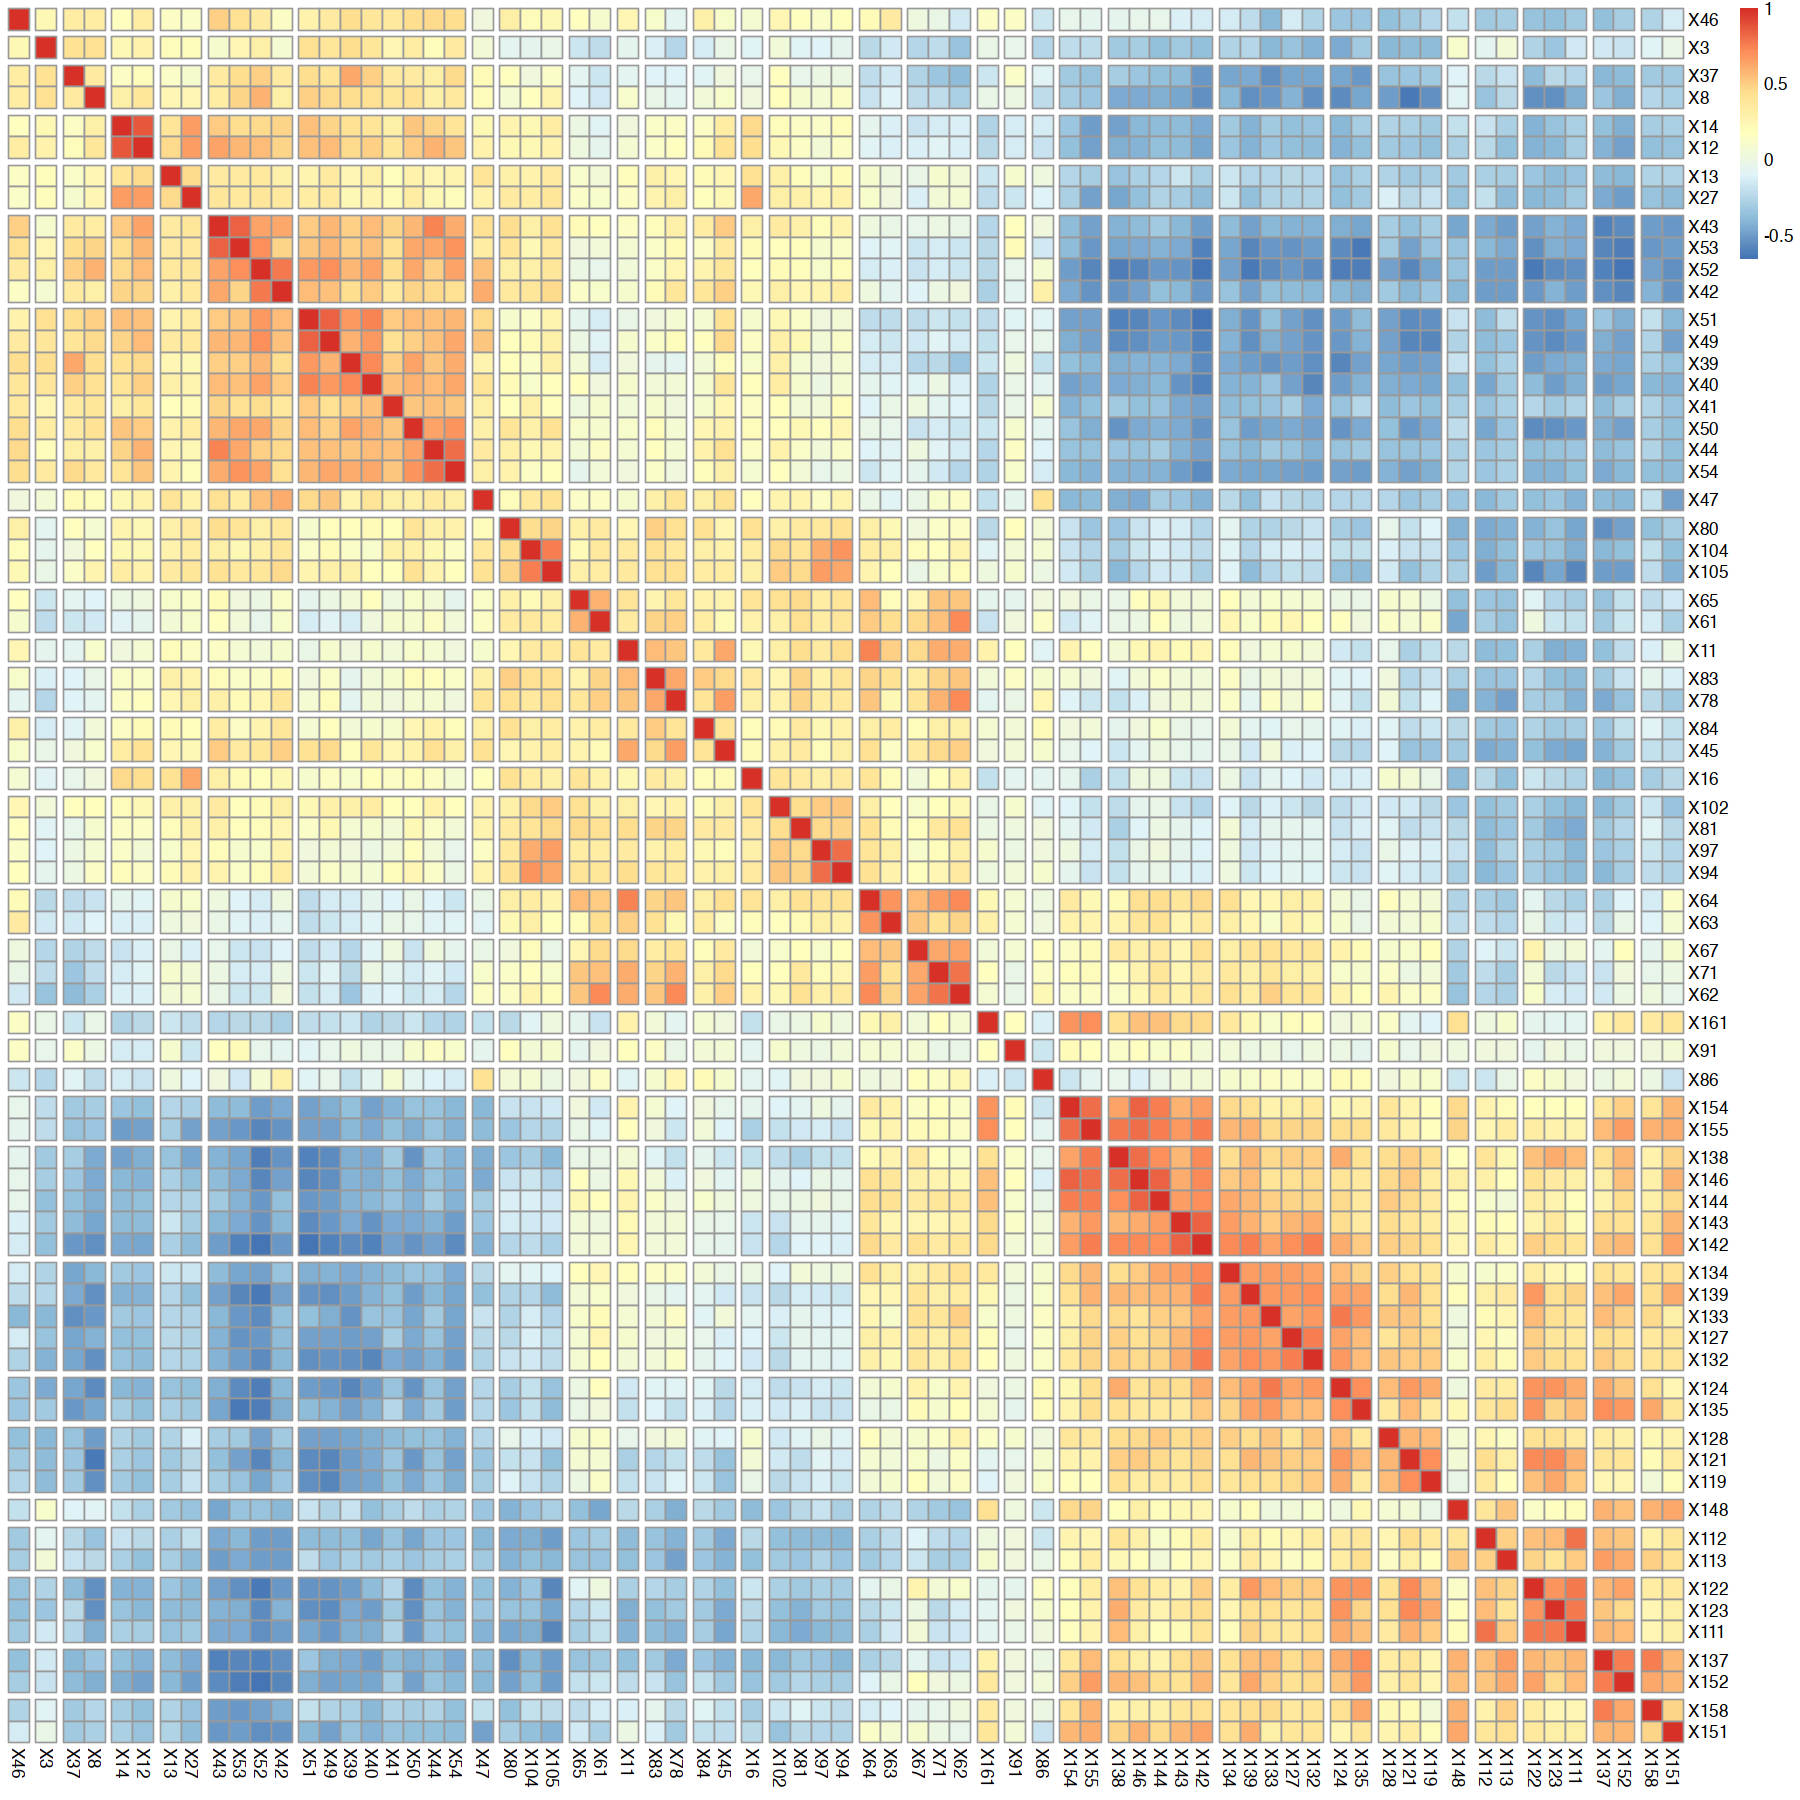

In [629]:
options(repr.plot.width = 15, repr.plot.height = 15)

pheatmap::pheatmap(cor(lipid_mat),cutree_cols=30,cutree_rows=30,treeheight_col=0,treeheight_row = 0)

In [615]:
names(accuracies) = as.character(num_clusters)

In [616]:
accuracies

5      10      15      20      25      30      35      40      45      50 
0.78125 0.84375 0.81250 0.87500 0.84375 0.90625 0.90625 0.90625 0.87500 0.90625 
     55      60      65      70      71 
0.93750 0.93750 0.90625 0.96875 0.90625

In [617]:
dist_mat$accuracy = accuracies[as.character(dist_mat$ncluster)]

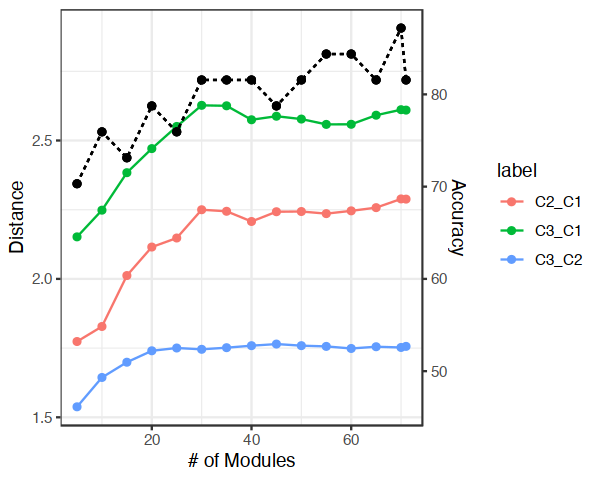

In [624]:
options(repr.plot.width = 5, repr.plot.height = 4)

ggplot(dist_mat,aes(ncluster,value,col=label))+
    geom_point()+
    geom_line(aes(group=label))+
    geom_point(aes(y=accuracy*3),col='black')+
    geom_line(aes(y=accuracy*3,group=label),linetype='dashed',col='black')+
    theme_bw()+
    ylab('Distance')+
    xlab('# of Modules')+
    scale_y_continuous(
    
    # Features of the first axis
        name = "Distance",
    
    # Add a second axis and specify its features
        sec.axis = sec_axis(~.*30, name="Accuracy")
    )

In [570]:
lipid_mat = data.frame(t(lipid_mat))
became_mat = lipid_mat[rownames(subset(meta_merged,grepl('^B',cluster))),]
became_mat$group = subset(meta_merged,grepl('^B',cluster))$cluster

In [579]:
make_rf(keeps)

ERROR: Error in model.frame.default(formula = formula, data = became_mat[1:round(nrow(became_mat) * : variable lengths differ (found for 'X51')


In [595]:
predictions_became

X10380 X10381 X10382 X10408 X10409 X10410 X10411 X10413 X10414 X10443 X10444 
 B-CTL     B2     B1     B2     B3     B2     B2  B-CTL     B3     B2     B2 
X10446 X10447 X10448 X10449 X10461 X10464 X10465 X10466 X10467 X10468 X10469 
    B2     B2     B2  B-CTL     B1     B2     B1     B2     B3     B2     B2 
X10470 X10498 X10501 X10502 X10503 X10504 X10505 X10506 X10507 X10535 X10538 
    B2     B3     B3     B3     B3     B2     B3     B2     B3     B2     B2 
X10539 X10540 X10541 X10542 X10543 X10544 X10595 X10598 X10599 X10600 X10601 
 B-CTL     B3     B2     B3  B-CTL  B-CTL     B3     B1     B2     B2     B2 
X10602 X10604 X10632 X10635 X10636 X10637 X10638 X10639 X10640 X10641 
 B-CTL     B1     B3  B-CTL     B2  B-CTL     B2     B3     B2  B-CTL 
Levels: B-CTL B1 B2 B3

In [596]:
 became_mat[round(nrow(became_mat)*.7):nrow(became_mat),'group']

[1] B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL
[13] B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL
[25] B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL
[37] B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL
[49] B-CTL B-CTL B-CTL B-CTL B-CTL B-CTL
Levels: B-CTL B1 B2 B3

In [599]:
make_rf<-function(keep){
    set.seed(456)
    
    became_mat = became_mat[which(became_mat$group!='B-CTL'),]
    became_mat$group =factor(as.character(became_mat$group))
    # Define your formula for classificatio7
    formula <- group~.
    # Train the Random Forest classifier
    rf_model_allClusters <- randomForest(formula, 
                             data = became_mat[1:round(nrow(became_mat)*.7),c(keep,'group')], 
                             ntree = 1000)
    
    predictions_became <- predict(rf_model_allClusters, became_mat[round(nrow(became_mat)*.7):nrow(became_mat),keeps], type = "response")
    accuracy_became <- mean(predictions_became == became_mat[round(nrow(became_mat)*.7):nrow(became_mat),'group'])
    return(accuracy_became)
}

In [586]:
became_mat$group = factor(became_mat$group)

In [587]:
  keep = keeps  
    # Define your formula for classificatio7
    formula <- group~.
    # Train the Random Forest classifier
    rf_model_allClusters <- randomForest(formula, 
                             data = became_mat[1:round(nrow(became_mat)*.7),c(keep,'group')], 
                             ntree = 1000)

In [589]:
predictions_became

X10380 X10381 X10382 X10408 X10409 X10410 X10411 X10413 X10414 X10443 X10444 
 B-CTL     B2     B1     B2     B3     B2     B2  B-CTL     B3     B2     B2 
X10446 X10447 X10448 X10449 X10461 X10464 X10465 X10466 X10467 X10468 X10469 
    B2     B2     B2  B-CTL     B1     B2     B1     B2     B3     B2     B2 
X10470 X10498 X10501 X10502 X10503 X10504 X10505 X10506 X10507 X10535 X10538 
    B2     B3     B3     B3     B3     B2     B3     B2     B3     B2     B2 
X10539 X10540 X10541 X10542 X10543 X10544 X10595 X10598 X10599 X10600 X10601 
 B-CTL     B3     B2     B3  B-CTL  B-CTL     B3     B1     B2     B2     B2 
X10602 X10604 X10632 X10635 X10636 X10637 X10638 X10639 X10640 X10641 
 B-CTL     B1     B3  B-CTL     B2  B-CTL     B2     B3     B2  B-CTL 
Levels: B-CTL B1 B2 B3

In [588]:
  
predictions_became <- predict(rf_model_allClusters, became_mat[round(nrow(became_mat)*.7):nrow(became_mat),keeps], type = "response")
accuracy_became <- mean(predictions_became == became_mat[round(nrow(became_mat)*.7):nrow(became_mat),'group'])
return(accuracy_became)

[1] 0.1851852

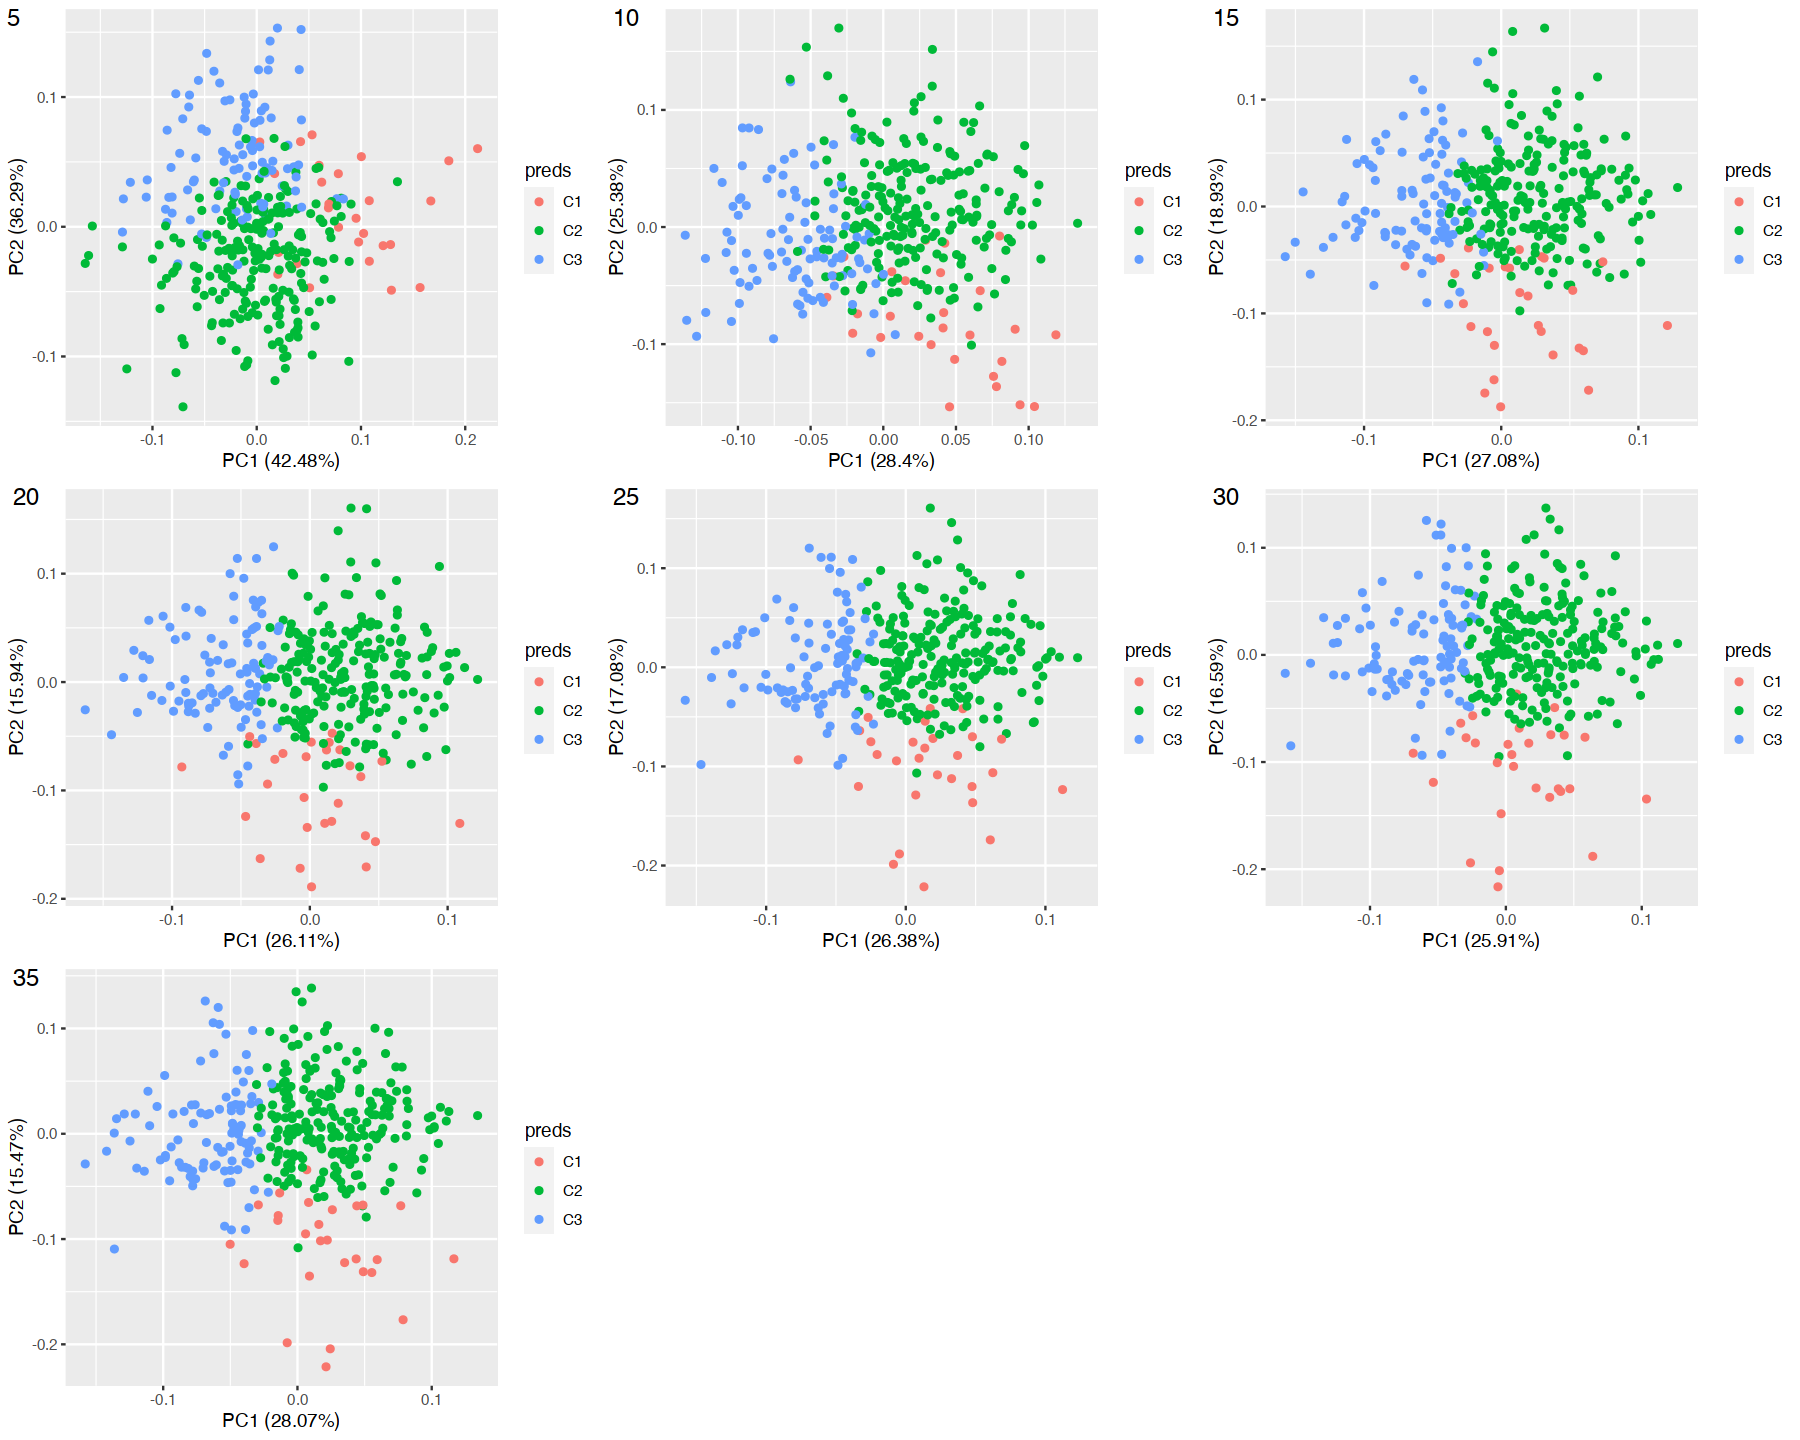

In [516]:
options(repr.plot.width = 15, repr.plot.height = 12)


cowplot::plot_grid(plotlist = plots,labels=names(plots))

In [458]:
keep_first_element <- function(df, vector) {
  df %>%
    group_by(column) %>%
    arrange(row_number()) %>%
    filter(row_number() == min(match(column, vector)))
}


In [462]:
minimal_signature$column = rownames(minimal_signature)

In [460]:
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [463]:
keep_first_element(minimal_signature,c('X49','X146'))

MeanDecreaseGini,lipid_id_became,lipid_id_miracle,lipid_class,modified_became_id,column
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
0.9758354,PC(O-18:0/18:2)-b,PC(O-17:0/20:4),Phosphatidylcholine ethers,PC(O-18:0/18:2)-b,X49


ERROR: Error in `[.data.frame`(data_merged, , keeps): undefined columns selected


In [442]:
data = lipid_mat
  while (TRUE) {
    # Find the indices of the most significant correlation
      p_values = find_pvals(t(data))
      p_values = data.frame(p_values)
      if (min(p_values[!is.na(p_values)])>0.01||nrow(p_values)<3) {
        break
      }
      rownames(p_values) = colnames(p_values)
      p_values$id = rownames(p_values)
      m = na.omit(reshape2::melt(p_values,id.var='id'))
      m = m[order(m$value),]
      most_sign = m[1,]
      
      # Break the loop if no correlated features found
      
      
      # Extract indices of correlated features
      feature1 <- as.character(most_sign[1,1])
      feature2 <- as.character(most_sign[1,2])
      
      # Print or save information about the pruned feature
      cat("Pruning feature:", feature2, "due to correlation with", feature1, "\n")
      
      # Prune one of the correlated features (e.g., feature2)
      keep = colnames(data)[colnames(data)!=feature2]
        data=data[,keep]
    }
    #return(data)


In [430]:
lipid_mat = lipid_mat[,-ncol(lipid_mat)]

In [434]:
head(lipid_mat)

,X10299,X10301,X10302,X10303,X10304,X10305,X10306,X10308,X10309,X10310,⋯,X12458,X12464,X12466,X12468,X12470,X12472,X12474,X12477,X12478,X12486
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X51,-0.8983013,1.5673011,0.3437970,0.3174055,0.7905969,0.7477933,1.1357099,-1.0064576,0.8138815,-0.5377583,⋯,2.2947220,0.06511923,-1.7740802,-0.43541607,1.31254426,-0.09580693,2.0753975,1.926343,0.2359020,-0.3281066
X43,-0.2016719,0.8596955,-0.1094208,0.6907628,0.1840501,-0.9148951,-0.4688171,0.5012938,0.4808691,-0.5603863,⋯,1.4063763,0.18836331,-2.0823492,0.10898417,-0.08959709,-0.66156880,1.3517705,1.074162,0.8390764,1.1419215
X146,-0.5640240,-0.6156508,0.5385056,0.1533858,1.0448089,-1.9065258,-0.8198813,1.7955356,-0.3574746,1.0470289,⋯,-1.1611304,0.69443165,2.6794912,0.47671344,-1.84131672,-0.68388440,0.2185668,-1.474852,0.4123115,0.2306210
X49,-1.6516606,1.0723487,0.3536093,0.4386753,0.2066600,-0.2588288,1.5092355,-0.3027485,0.1924047,-0.4696892,⋯,1.7900502,-0.75313452,-2.1402194,-0.03811169,1.24737604,0.18826896,0.8517841,2.279958,0.1355864,-0.6604373
X154,-0.6033820,-0.6934522,0.6875676,-0.4152530,1.2407630,-1.3889706,-0.7720254,2.6980386,-0.2290988,1.0498372,⋯,-1.3643011,0.64888516,2.3344199,-0.51305977,-1.12440397,-0.46267065,0.4630728,-1.237816,0.2739269,0.2985845
X127,1.3319551,1.2648452,-0.3660050,0.4306476,-1.2174460,-1.1579708,0.4024149,0.5548810,0.9615934,-0.5499536,⋯,-0.7173479,0.83132896,0.9145701,0.99480292,0.87361861,0.08064773,-1.3909638,-1.077542,-1.6210620,0.1273466


In [437]:
dim(pf)

[1] 71  0

In [439]:
pf = prune_correlated_features(lipid_mat)

Pruning feature: X14 due to correlation with X12 


ERROR: Error in cor.test.default(as.numeric(data[, i]), as.numeric(data[, j])): not enough finite observations


In [426]:
data = lipid_mat



  


Pruning feature: X14 due to correlation with X12 


In [407]:
prune_correlated_features(lipid_mat)

ERROR: Error in dimnames(x) <- dn: length of 'dimnames' [2] not equal to array extent


In [366]:
m = na.omit(reshape2::melt(tmp))
m = m[order(m$value),]
remove = subset(m,value<0.01)$variable[2:nrow(subset(m,value<0.01))]
lipid_mat = lipid_mat[!rownames(lipid_mat)%in%remove,]

No id variables; using all as measure variables



,variable,value
,<fct>,<dbl>
2,X14,9.877394e-112
3,X12,9.877394e-112


In [345]:
p_values= data.frame(p_values)

In [346]:
rownames(p_values) = colnames(p_values)

In [347]:
rownames(lipid_mat[which(lipid_mat$clusters==1),])[!rownames(lipid_mat[which(lipid_mat$clusters==1),])%in%rownames(p_values)]

character(0)

In [348]:
p_values[rownames(lipid_mat[which(lipid_mat$clusters==1),]),rownames(lipid_mat[which(lipid_mat$clusters==1),])]

,X51,X43,X49,X41,X11,X83,X53,X3,X16,X52,⋯,X8,X14,X54,X105,X50,X12,X40,X45,X27,X46
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X51,NA,3.419926e-25,1.681359e-93,4.182237e-24,8.262893e-01,5.356867e-01,3.829028e-26,8.902240e-17,4.842475e-02,1.910457e-49,⋯,1.032480e-22,6.627987e-29,1.287516e-33,4.987496e-07,9.274586e-31,1.210701e-29,3.813807e-65,1.699604e-15,1.505267e-10,1.171410e-07
X43,3.419926e-25,NA,2.392362e-33,7.879805e-22,3.352547e-03,1.399924e-04,1.841422e-93,7.750286e-02,4.262286e-09,9.306253e-43,⋯,2.817604e-10,3.871333e-24,5.237133e-37,2.921267e-16,3.109672e-33,8.320655e-42,4.709613e-31,1.996444e-25,4.698323e-14,1.912923e-22
X49,1.681359e-93,2.392362e-33,NA,6.154644e-17,8.403622e-02,1.290842e-02,1.119092e-32,2.157704e-13,4.359819e-03,1.053780e-56,⋯,2.176871e-19,5.185144e-22,1.423753e-39,1.684633e-08,4.799537e-24,6.687643e-31,6.739405e-49,2.290593e-20,4.256043e-12,2.034001e-11
X41,4.182237e-24,7.879805e-22,6.154644e-17,NA,3.886088e-01,8.876604e-02,6.631897e-17,4.379179e-06,7.760787e-03,5.481822e-19,⋯,4.834476e-13,8.646959e-10,5.796573e-27,4.721612e-04,7.007874e-27,1.757090e-13,9.060866e-29,2.610446e-06,4.719205e-05,2.754184e-12
X11,8.262893e-01,3.352547e-03,8.403622e-02,3.886088e-01,NA,5.275711e-30,1.277681e-01,3.510257e-01,9.388712e-06,2.880350e-01,⋯,4.354308e-02,5.133385e-01,6.226523e-01,1.082194e-12,3.608285e-02,9.750344e-02,6.554037e-02,7.471174e-40,5.083812e-03,2.575225e-06
X83,5.356867e-01,1.399924e-04,1.290842e-02,8.876604e-02,5.275711e-30,NA,1.001845e-02,4.125138e-02,4.912235e-11,1.347891e-02,⋯,8.197990e-01,8.844768e-03,1.271942e-02,8.502876e-17,1.912160e-04,9.827438e-03,3.776085e-01,4.932387e-20,1.091827e-06,2.529412e-02
X53,3.829028e-26,1.841422e-93,1.119092e-32,6.631897e-17,1.277681e-01,1.001845e-02,NA,1.362755e-06,2.528072e-05,1.165205e-56,⋯,4.265405e-21,1.726458e-18,3.010195e-52,3.535330e-12,5.865307e-39,9.499388e-33,1.898246e-29,2.714757e-11,3.107675e-12,8.538781e-17
X3,8.902240e-17,7.750286e-02,2.157704e-13,4.379179e-06,3.510257e-01,4.125138e-02,1.362755e-06,NA,1.009233e-01,1.686277e-09,⋯,1.240717e-16,1.344036e-05,1.873014e-11,8.564291e-01,1.706717e-10,9.435995e-08,1.101578e-13,6.985523e-01,1.463258e-04,1.886302e-05
X16,4.842475e-02,4.262286e-09,4.359819e-03,7.760787e-03,9.388712e-06,4.912235e-11,2.528072e-05,1.009233e-01,NA,1.065194e-03,⋯,4.788637e-01,2.305909e-19,9.267671e-02,6.487419e-09,1.245039e-04,5.267685e-18,3.844938e-04,6.957213e-05,6.535136e-40,1.616628e-01


In [309]:
m = reshape2::melt(p_values)

In [310]:
m

Var1,Var2,value
<int>,<int>,<dbl>
1,1,NA
2,1,3.419926e-25
3,1,1.625583e-33
4,1,1.681359e-93
5,1,1.319238e-21
6,1,3.318795e-22
7,1,8.019778e-05
8,1,4.182237e-24
9,1,4.357055e-34


In [305]:
cor(data_merged[,rownames(minimal_signature)])

,X51,X43,X146,X49,X154,X127,X64,X41,X138,X112,⋯,X105,X50,X113,X67,X12,X40,X45,X27,X86,X46
X51,1.00000000,0.5146032684,-0.58361813,0.83660601,-0.47916687,-0.48538368,-0.20863011,0.50428835,-0.58781478,-0.37332229,⋯,0.264096652,0.56249378,-0.21864178,-0.22208507,0.55349113,0.751310789,0.40726171,0.33278416,-0.080741794,0.27779030
X43,0.51460327,1.0000000000,-0.37889354,0.58237483,-0.38171974,-0.40600770,0.02254505,0.48150323,-0.41679432,-0.44358131,⋯,0.417256300,0.58152803,-0.50092471,-0.02763866,0.63910460,0.564823436,0.51677557,0.38745734,0.030681323,0.48783069
X146,-0.58361813,-0.3788935362,1.00000000,-0.54199592,0.84878747,0.43277334,0.42525091,-0.36901978,0.80653050,0.29127555,⋯,-0.240273486,-0.44663649,0.18845345,0.29324981,-0.41175425,-0.438432574,-0.06814508,-0.36067327,-0.114826783,-0.03469007
X49,0.83660601,0.5823748309,-0.54199592,1.00000000,-0.43564477,-0.47968323,-0.13387490,0.42582621,-0.57076217,-0.38769191,⋯,0.295029141,0.50371088,-0.32433644,-0.14888537,0.56362028,0.678947564,0.46589151,0.35823225,-0.034935111,0.34735067
X154,-0.47916687,-0.3817197442,0.84878747,-0.43564477,1.00000000,0.31590242,0.35147394,-0.41237426,0.64111344,0.27031017,⋯,-0.150501774,-0.34411996,0.19950397,0.14551608,-0.37049832,-0.473901414,-0.03136532,-0.28241041,-0.168924731,-0.03111389
X127,-0.48538368,-0.4060076958,0.43277334,-0.47968323,0.31590242,1.00000000,0.31025475,-0.30295434,0.49376627,0.24641557,⋯,-0.202307097,-0.44499855,0.14317259,0.36884651,-0.37030495,-0.474564766,-0.12003687,-0.26386754,0.138335382,-0.12533871
X64,-0.20863011,0.0225450489,0.42525091,-0.13387490,0.35147394,0.31025475,1.00000000,-0.09598776,0.20666589,-0.28858277,⋯,0.263570216,-0.01996344,-0.31426577,0.56870584,-0.07888680,-0.056941597,0.42204187,0.12324998,0.023903700,0.21604670
X41,0.50428835,0.4815032290,-0.36901978,0.42582621,-0.41237426,-0.30295434,-0.09598776,1.00000000,-0.30948268,-0.35267041,⋯,0.185382938,0.52995352,-0.27520361,0.01881982,0.37920278,0.546241955,0.24744820,0.21510552,0.081236101,0.36118733
X138,-0.58781478,-0.4167943215,0.80653050,-0.57076217,0.64111344,0.49376627,0.20666589,-0.30948268,1.00000000,0.39638435,⋯,-0.397746705,-0.53488792,0.23031462,0.34368655,-0.43628445,-0.441750825,-0.16620816,-0.46221413,-0.040556800,-0.04759567
X112,-0.37332229,-0.4435813108,0.29127555,-0.38769191,0.27031017,0.24641557,-0.28858277,-0.35267041,0.39638435,1.00000000,⋯,-0.497423850,-0.46943882,0.49819619,-0.09830447,-0.23769771,-0.468625243,-0.44574612,-0.19111900,-0.173040902,-0.31550416


In [718]:
head(meta_merged)

,id,group,cluster,cohort,preds
,<int>,<chr>,<chr>,<chr>,<chr>
X10299,10299,HFpEF,B3,BECAME,C3
X10301,10301,HFpEF,B2,BECAME,C2
X10302,10302,HFpEF,B2,BECAME,C2
X10303,10303,HFpEF,B2,BECAME,C2
X10304,10304,HFpEF,B1,BECAME,C1
X10305,10305,HFpEF,B1,BECAME,C1


In [719]:
became = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=1))
miracle = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=1))

became_meta = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=2))
miracle_meta = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=2))

New names:
• `ID-LCMS` -> `ID-LCMS...1`
• `ID-LCMS` -> `ID-LCMS...16`


In [720]:
became_num = became[,-c(1:7)]
miracle_num = miracle[,-c(1:7)]


became_tmp = became_meta[,c(1:3)]
miracle_tmp = miracle_meta[,c(1:3)]
colnames(became_tmp) = c('id','group','cluster')
colnames(miracle_tmp) = c('id','group','cluster')

became_tmp$cluster = paste0('B',became_tmp$cluster)
miracle_tmp$cluster = paste0('M',miracle_tmp$cluster)

became_tmp$cohort = 'BECAME'
miracle_tmp$cohort = 'MIRACLE'

meta = rbind(became_tmp,miracle_tmp)
rownames(meta) = paste0('X',meta$id)

In [734]:
head(miracle_num)

,X12203,X12205,X12206,X12208,X12210,X12211,X12213,X12214,X12216,X12218,⋯,X12439,X12440,X12480,X12482,X12484,X12488,X12489,X12491,X12493,X12494
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,161941.39,63359.47,123661.54,114150.88,92038.86,153563.52,120186.60,102789.25,111927.34,163843.41,⋯,180424.17,70508.16,178837.48,122144.16,186179.8,128142.56,150883.56,109795.60,91394.92,122914.67
2,59606.33,43041.95,68132.85,45359.82,57280.03,89168.58,70021.52,56560.87,79189.68,99135.73,⋯,90801.34,31873.89,80880.37,48477.18,116686.8,62041.73,76836.59,44982.52,48832.74,73603.85
3,218779.88,109926.52,154960.04,117197.45,123028.98,292786.73,106429.99,122144.21,190281.80,223774.21,⋯,310269.07,68364.85,214701.22,251922.29,257634.0,134312.05,297115.87,115280.72,121749.08,138198.65
4,91122.29,44896.76,54188.01,49815.82,95997.80,116180.67,48086.58,67203.53,82576.55,121668.85,⋯,150635.60,31013.66,85900.34,113234.87,102264.4,61381.32,157484.85,36419.80,51566.18,105876.90
5,1028739.94,621707.61,558608.79,651916.94,1070732.58,708398.99,762763.60,892271.60,851293.28,705176.45,⋯,645064.32,643121.97,706596.19,442374.38,747166.0,587260.01,644464.75,758012.35,799816.77,634955.48
6,220295.18,103479.46,96962.27,131380.59,163477.18,137202.93,139837.09,160222.18,208069.64,148018.37,⋯,143508.23,134341.91,143004.54,73383.96,155643.1,106985.59,105595.49,137777.90,139034.85,130036.24


[1] 177 161
[1] 175 161


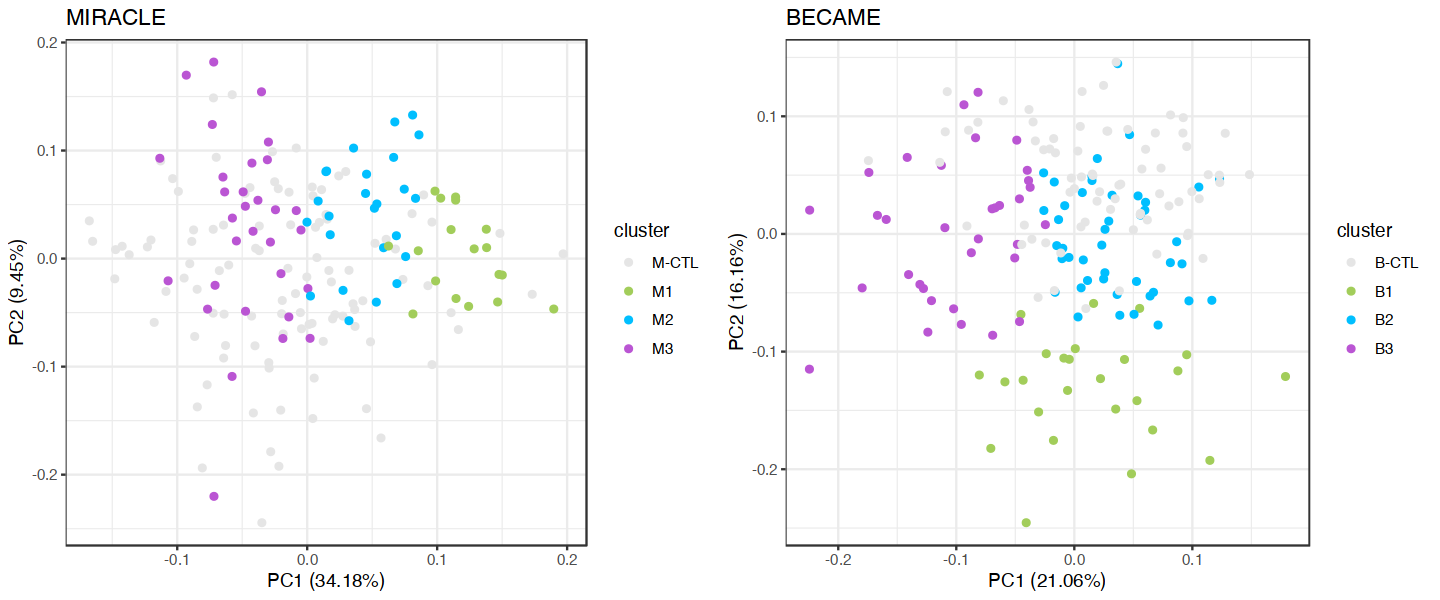

In [737]:
for(i in 1:ncol(miracle_num)){miracle_num[,i]=as.numeric(miracle_num[,i])}
pca = prcomp(scale(log(t(miracle_num))))
print(dim(pca$x))
meta$cluster[meta$cluster=='MNA']='M-CTL'
meta_merged[grepl('CTL',meta_merged$cluster),'preds']='CTL'

p1 = autoplot(pca,data=meta_merged[colnames(miracle_num),],col='cluster')+theme_bw()+scale_color_manual(values=c('grey90','darkolivegreen3','deepskyblue','mediumorchid'))

for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}
keep_patients = rownames(subset(meta_merged,!is.na(preds) & cohort=='BECAME'))
pca = prcomp(scale(log(t(became_num[,keep_patients]))))
print(dim(pca$x))
meta$cluster[meta$cluster=='BCtrl']='B-CTL'
p2 = autoplot(pca,meta_merged[keep_patients,],col='cluster')+scale_color_manual(values=c('grey90','darkolivegreen3','deepskyblue','mediumorchid','grey90'))+theme_bw()


options(repr.plot.width = 12, repr.plot.height = 5)

cowplot::plot_grid(p1+ggtitle('MIRACLE'),
                   p2+ggtitle('BECAME'),ncol=2)

[1] 177 161
[1] 175 161


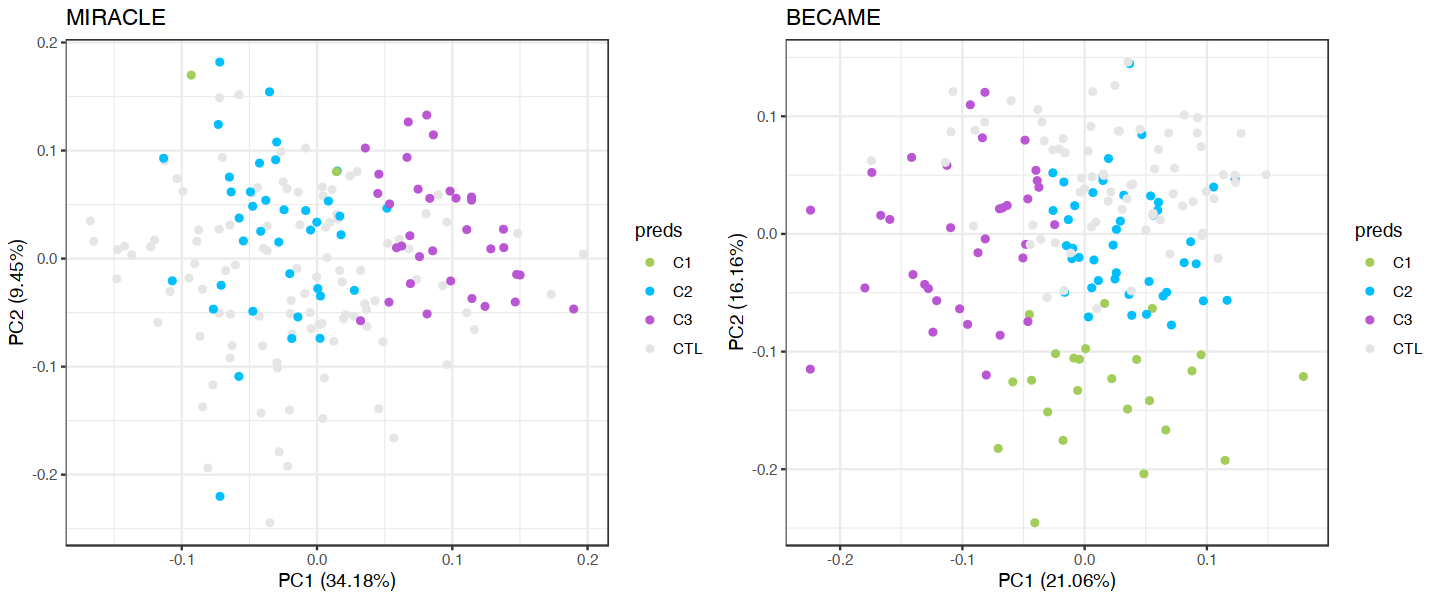

In [739]:
for(i in 1:ncol(miracle_num)){miracle_num[,i]=as.numeric(miracle_num[,i])}
pca = prcomp(scale(log(t(miracle_num))))
print(dim(pca$x))
meta$cluster[meta$cluster=='MNA']='M-CTL'
meta_merged[grepl('CTL',meta_merged$cluster),'preds']='CTL'

p1 = autoplot(pca,data=meta_merged[colnames(miracle_num),],col='preds')+theme_bw()+scale_color_manual(values=c('darkolivegreen3','deepskyblue','mediumorchid','grey90'))

for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}
keep_patients = rownames(subset(meta_merged,!is.na(preds) & cohort=='BECAME'))
pca = prcomp(scale(log(t(became_num[,keep_patients]))))
print(dim(pca$x))
meta$cluster[meta$cluster=='BCtrl']='B-CTL'
p2 = autoplot(pca,meta_merged[keep_patients,],col='preds')+scale_color_manual(values=c('darkolivegreen3','deepskyblue','mediumorchid','grey90'))+theme_bw()


options(repr.plot.width = 12, repr.plot.height = 5)

cowplot::plot_grid(p1+ggtitle('MIRACLE'),
                   p2+ggtitle('BECAME'),ncol=2)